### **New Fuzzy System Cheat Sheet**

##### ***Libraries***

In [2]:
from sympy import symbols, solve, Eq
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal

##### ***Useful functions***

In [3]:
def triangle(mu:float, c:float, x:np.ndarray[float]) -> np.ndarray[float]:
    y = np.zeros_like(x)
    
    INNER_LEFT = np.logical_and(x>=mu-c, x<=mu)
    INNER_RIGHT = np.logical_and(x>=mu, x<=mu+c)
    
    y[INNER_LEFT] = 1 + (x[INNER_LEFT]-mu)/c
    y[INNER_RIGHT] = 1 - (x[INNER_RIGHT]-mu)/c
    
    return y

def asymmetricTriangle(mu:float, c1:float, c2:float, x:np.ndarray[float]) -> np.ndarray[float]:
    y = np.zeros_like(x)
    
    INNER_LEFT = np.logical_and(x>=mu-c1, x<=mu)
    INNER_RIGHT = np.logical_and(x>=mu, x<=mu+c2)
    
    y[INNER_LEFT] = 1 + (x[INNER_LEFT]-mu)/c1
    y[INNER_RIGHT] = 1 - (x[INNER_RIGHT]-mu)/c2
    
    return y

def linearstep(mu, c:float, x:np.ndarray[float]) -> np.ndarray[float]:
    y = np.zeros_like(x)
    
    INNER_LEFT = np.logical_and(x>=c, x<=mu)
    OUTER_RIGHT = x>=mu
    
    y[INNER_LEFT] = (x[INNER_LEFT]-c)/(mu-c)
    y[OUTER_RIGHT] = 1
    
    return y

X = np.linspace(0,1,10**4)

#### **Skill-Expertise Set**
S^p Skill-Expertise Set is a set of pair associating a skill to a corresponding expertise. Initially, they can be represented as 
$$
S = \left\{\left(s_1, e_{s_1}\right),\left(s_2, e_{s_2}\right),\cdots, \left(s_n, e_{s_n}\right)\right\}
$$
Where $s_i$ is the $i$-th skill and $e_{s_i}$ the associated expertise (graded or Fuzzy I).

These Skill-Expertise Sets can be classified further down into two category:
- **Provider:** For resumes and outcomes of trainings.
- **Requirement:** For requirements of jobs and trainings.

If we want to apply 2nd fuzzification on top of Fuzzy I Skill-Expertise Set, then we can secede the *Provider Skill-Expertise Set* and the *Requirement Skill-Expertise Set* into distinct entities as:

- **Provider Skill-Expertise Set:** $S^p = \left\{\left(s_1^p, e_{s_1^p}, cl_{s_1^p}, cr_{s_1^p}\right),\left(s_2^p, e_{s_2^p}, cl_{s_2^p}, cr_{s_2^p}\right),\cdots, \left(s_n^p, e_{s_n^p}, cl_{s_n^p}, cr_{s_n^p}\right)\right\}$
- **Requirement Skill-Expertise Set:** $S^r = \left\{\left(s_1^r, e_{s_1^r}, c_{s_1^r}\right),\left(s_2^r, e_{s_2^r}, c_{s_2^r}\right),\cdots, \left(s_n^r, e_{s_n^r}, c_{s_n^r}\right)\right\}$

Where $s_i^{r|p}$ is the $i$-th skill, $e_{s_i^{r|p}}$ the associated expertise and $c\{l|r\}_{s_i^{r|p}}$ the associated confidence to the left or to the right for the Provider and to the left for the requirement.

**Important: The confidence format is different for both type of set. For provider, confidence is relative to the central expertise, while for requirement, it represent the point to which the employer accept the difference.**

In Type II Fuzzification, we can represent $S^p$ as a triangle representing the confidence on the provided expertise. It would answer the question: *"What is the maximum expertise provided by the training/CV?"*. $S^r$ is represented as a linear step function and answer the question: *"What expertise is accepted to participate to the training/apply to the job position?"* 

Here is a representation of the following fuzzy Sets:
- $S^r = \left\{\left(\text{Py}, 0.8, 0.6\right),\left(\text{C}, 0.5, 0.4\right), \left(\text{PM}, 0.5, 0.2\right)\right\}$
- $S^p = \left\{\left(\text{Py}, 0.4, 0.1, 0.1\right),\left(\text{Java}, 0.8, 0.1, 0.2\right), \left(\text{PM}, 0.6, 0.2, 0.2\right)\right\}$

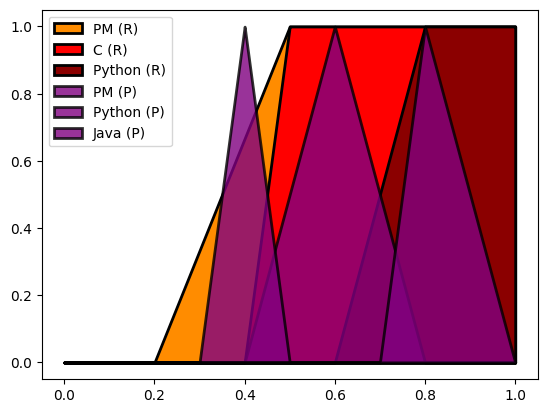

In [4]:
plt.fill_between(X, linearstep(0.5,0.2,X), color="darkorange", alpha=1, ec="black", lw=2, label="PM (R)")
plt.fill_between(X, linearstep(0.5,0.4,X), color="red", alpha=1, ec="black", lw=2, label="C (R)")
plt.fill_between(X, linearstep(0.8,0.6,X), color="darkred", alpha=1, ec="black", lw=2, label="Python (R)")

plt.fill_between(X, asymmetricTriangle(0.6,0.2,0.2,X), color="purple", alpha=0.8, ec="black", lw=2, label="PM (P)")
plt.fill_between(X, asymmetricTriangle(0.4,0.1,0.1,X), color="purple", alpha=0.8, ec="black", lw=2, label="Python (P)")
plt.fill_between(X, asymmetricTriangle(0.8,0.1,0.2,X), color="purple", alpha=0.8, ec="black", lw=2, label="Java (P)")

plt.legend(loc="upper left")

#### **Inclusion of Provider Skill-Expertise Set within Requirement Skill-Expertise Set**
Now, it becomes fairly interesting to ask a question. The basic axiom of our research is that the requirements $R$ are met by a provided Skill-Expertise Set $S$ iff $R\subseteq S$. But what does inclusion means after second fuzzification ?

If we take classical fuzzy inclusion (i.e. $X\subseteq Y \equiv \forall x \in\Omega : \mu_X(x)\le \mu_Y(x)$), then we return to a crisp threshold. This is why, to have a continuum of inclusion, we move to a different definition. We will talk of inclusion degree instead of binary inclusion. This inclusion degree is defined as:

$$
X \subseteq Y \equiv I(X,Y) = \frac{\#X\cap Y}{\#X}
$$

\**Consistency measure, inclusion degree and fuzzy measure in decision tables Yuhua Qian, Jiye Liang, Chuangyin Dang (Equation 1)*

In our case, we are interested into something simple. What is the inclusion of a *Provider Skill-Expertise Set* within a *Requirement Skill-Expertise Set*. Notice that the situation is reversed with the original paper, because we now consider "Acceptable expertise" for requirements instead of fully-fledged expertise.

The question now is: **Does a closed form formula or algorithm exists to determine the inclusion between linear step and triangular?**

##### **Functional Representation of Skill-Expertise Sets**
To answer this question we have to take a look at the function representation of both types of Skill-Expertise Set:

- $
S^p = \left\{\left(
        s_i^p, e_{s_i^p}, c_{s_i^p}
    \right)\right\} \equiv 
    \left\{\left(
        s_i^p, \begin{cases}
            1+\frac{(x-e_{s_i^p})}{cl_{s_i^p}} & e_{s_i^p}-cl_{s_i^p}\le x \le e_{s_i^p}\\
            1-\frac{(x-e_{s_i^p})}{cr_{s_i^p}} & e_{s_i^p}\le x \le e_{s_i^p}+cr_{s_i^p}\\
            0 & \text{otherwise}
        \end{cases}
    \right)\right\}
$

- $
S^r = \left\{\left(
        s_i^r, e_{s_i^r}, c_{s_i^r}
    \right)\right\} \equiv 
    \left\{\left(
        s_i^r, \min\left\{1,\max\left\{0,\frac{x-c_{s_i^r}}{e_{s_i^r}-c_{s_i^r}}\right\}\right\}
    \right)\right\}
$

**/!\ IMPORTANT WARNING: we suppose that $0 \le e_{s_i^p}-cl_{s_i^p}$ and $e_{s_i^p}+cr_{s_i^p} \le 1$ and $c_{s_i^r}\in[0,1]$ and $e_{s_i^r}\in[0,1]$.**

Now that we have the representation, we want to compute $I(S^p, S^r)=\frac{\#S^p\cap S^r}{\#S^p}$. For that we remind that cardinality of a fuzzy set is the integral over its support and that the intersection is the minimum. 

We have some trivial cases:
- **Disjonction:** $e_{s_i^p}+cr_{s_i^p} \le c_{s_i^r} \Rightarrow I(S^p, S^r) = 0$.
- **Full Inclusion:** $e_{s_i^p}-cl_{s_i^p} \ge c_{s_i^r} \land e_{s_i^p}\ge e_{s_i^r} \Rightarrow I(S^p, S^r) = 1$.

Still we have much more tricky cases. We have to evaluate them separately. For that we need to find eventual intersection points between the triangle and the linear step function.

In [5]:
# Symbols
x, ep, er, crp, clp, cr = symbols("x e_p e_r c_rp c_lp c_r")

# Functions for triangle
fxp1 = 1+(x-ep)/clp
fxp2 = 1-(x-ep)/crp

# Functions for linear step
fxr = (x-cr)/(er-cr)

In [6]:
# Intersection between step and first triangle half
solve(Eq(fxr, fxp1),x)[0]

(c_lp*e_r + c_r*e_p - e_p*e_r)/(c_lp + c_r - e_r)

In [7]:
# Intersection between step and second triangle half
solve(Eq(fxr, fxp2), x)[0] 

(-c_r*e_p + c_rp*e_r + e_p*e_r)/(-c_r + c_rp + e_r)

We now have the intersection following intersection points:

- $i_{x_1} = \frac{cl_{p}e_{r} + c_{r}e_{p} - e_{p}e_{r}}{cl_{p} + c_{r} - e_{r}}$
- $i_{x_2} = \frac{cr_{p}e_{r} - c_{r}e_{p} + e_{p}e_{r}}{cr_{p} - c_{r} + e_{r}}$

From these, we can evacuate one trivial case:

- **Left/Right phantom intersection:** If $i_{x_1} \le \min\left\{e_{s_i^p}-cl_{s_i^p}, c_{s_i^r}\right\}\lor i_{x_1}\ge e_{s_i^r}$ or is undefined, then either the affines are parallel or non secant between 0 and 1 and $S^r$ is always the last to start moving up (otherwise, it would be full inclusion). In this case, we always integrate $S^r$ from $c_{s_i^r}$ to $i_{x_2}$ (which always exists unless fully included or fully excluded). Then we integrate $S^p$ from $i_{x_2}$ to $c_{e_i^p}+cr_{s_i^p}$.

Because $\forall x \ge i_{x_2} : S^p\le S^R$, we always integrate on $S^p$ after $i_{x_2}$. 

The only thing is to know now is that if the first intersection exists (non phantom), then which function is minimum before and which is minimum after $i_{x_1}$. For that we will see which support is appearing last on the x-line: 

- If it is $S^p$, then we integrate $S^p$ between $e_{s_i^p}-cl_{s_i^p}$ and $i_{x_1}$, then $S^r$ from $i_{x_1}$ to $c_{s_i^r}$. 
- If it is $S^r$, then we integrate $S^r$ between $c_{s_i^r}$ to $i_{x_1}$, then $S^p$ from $i_{x_1}$ to $e_{s_i^p}$ and add the integration of $S^p$ from $e_{s_i^p}$ to $e_{s_i^p}+cr_{s_i^p}$ because $\forall x\ge i_{x_1} : S^r(x)\ge S^p(x)$ in this case.

Sill, one edge case can happen. If $c_{s_i^r}=e_{s_i^r}$ then $i_{x_1}=i_{x_2}$. In this case, we should integrate $0$ from $0$ to $i_{x_1}$ (which render 0), then integrate $S^p$, which is always minimum after $i_{x_1}$ (because the linear step has transformed into full step).

##### **Inclusion Degree between provider and requirement Skill-Expertise Sets Algorithm**

We now have an algorithm to compute the inclusion of a *provider Skill-Expertise Set* within a *requirement Skill-Expertise Set*. We can formalise it as: 

```vb
ALGO InclusionDegree:
    INPUT:
        - ep: Provider expertise center.
        - cpl: Provider expertise confidence on the left.
        - cpr: Provider expertise confidence on the right.
        - er: Required expertise center.
        - cr: Required expertise confidence.
    OUTPUT:
        - I(Sp,Sr): Inclusion degree of provided given required.
    
    START
        'Trivial cases
        ''Full Disjonction
        IF ep + cpr < cr THEN
            RETURN 0
        ''Full Inclusion
        ELSE IF ep - cpl >= cr && ep >= er THEN
            RETURN 1
        END IF
 
        FUNCTION R(x): (x-cr)/(er-cr)
        FUNCTION P1(x): 1+(x-ep)/cpl
        FUNCTION P2(x): 1-(x-ep)/cpr

        'Compute the intersections and area under the whole triangle
        ix1 <- (cpl*er+cr*ep-er*ep)/(cr+cpl-er)
        ix2 <- (cpr*er-cr*ep+ep*er)/(cpr-cr+er)
        Xp <- (cpr+cpl)/2

        'No triangle width case
        IF Xp == 0 THEN
            RETURN R(ix1)

        'Full step case
        ELSE IF cr == er THEN
            ''Provider max left case
            IF ep <= er THEN
                integral <- (ep+cpr-ix2)*P2(ix2)/2
            ''Provider max right case
            ELSE IF ep > er THEN
                integral <- (P2(ix2)*(ep-ix2)+ep-ix2+cpr)/2
            END IF

        'Phantom intersection case
        IF ix1 <= MIN(ep-cpl, cr) || ix1 >= er || IS_UNDEFINED(ix1) THEN
            integral <- R(ix2)*(ep+cpr-cr)/2

        'Requirement start first case
        ELSE IF cr <= ep-cpl THEN
            integral <- (P1(ix1)*(cpl-ep+ix2) + P2(ix2)*(cpr+ep-ix1))/2
        
        'Provider start first case
        ELSE IF ep - cpl <= cr THEN
            integral <- (P1(ix1)*(ep-cr) + ep - ix1 + cpr)/2
        END IF

        RETURN integral/Xp
    END
```

For the computation and proofs, you can play visually with Desmos: https://www.desmos.com/calculator/gsgfh2xhtu

##### **Small Experiments**
Given:
- $S^r = \left\{\left(\text{Py}, 0.8, 0.6\right),\left(\text{C}, 0.5, 0.4\right), \left(\text{PM}, 0.5, 0.2\right)\right\}$
- $S^p = \left\{\left(\text{Py}, 0.5, 0.2, 0.2\right),\left(\text{Java}, 0.8, 0.1, 0.1\right), \left(\text{PM}, 0.4, 0.2, 0.2\right)\right\}$

What is the Inclusion degree of each triangular into their respective requirements?

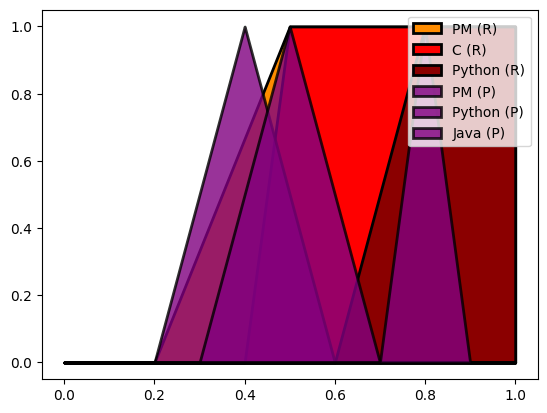

In [8]:
# Implementation of the algorithm
def InclusionDegree(provided:tuple[float,float,float], required:tuple[float,float]) -> float:
    ep, cpl, cpr = provided
    er, cr = required
    Xp = (cpr+cpl)/2

    # Full disjunction
    if ep + cpr < cr:
        return 0 
    # Full inclusion
    if ep - cpl >= cr and ep >= er:
        return 1
    
    # Functions    
    R = lambda x: (x-cr)/(er-cr)
    P1 = lambda x: 1+(x-ep)/cpl
    P2 = lambda x: 1-(x-ep)/cpr
    
    # Intersections and X area
    undef = False
    try:
        ix1 = (cpl*er + cr*ep - er*ep)/(cr + cpl - er)
    except ZeroDivisionError:
        undef = True
    try:
        ix2 = (cpr*er - cr*ep + ep*er)/(cpr - cr + er)
    except ZeroDivisionError:
        pass
    
    # No triangular width case
    if Xp == 0:
        return R(ep)

    # Full step case
    elif cr == er:
        # Left triangle subcase
        if ep <= er:
            integral = (ep+cpr-ix2)*P2(ix2)/2
        # Right triangle subcase
        elif ep > er:
            integral = (P2(ix2)*(ep-ix2)+ep-ix2+cpr)/2
    
    # Phantom Intersection Case
    elif undef or ix1 <= min(ep-cpl, cr) or ix1 >= er:
        integral = R(ix2) * (ep+cpr-cr)/2
    
    # Requirement start first case
    elif cr <= ep-cpl:
        # P1 and P2 were changed to R, because P1(ix1) and P2(ix2) is undefined if cpr = 0, 
        # but if phantom case is check first, then P(ix1) = R(ix1) and P(ix2) = R(ix2)
        integral = (R(ix1)*(cpl-ep+ix2) + R(ix2)*(cpr+ep-ix1))/2
        
    # Provider start first case
    elif ep - cpl <= cr:
        # P1 was changed to R, because P1(ix1) is undefined if cpr = 0, 
        # but if phantom case is check first, then P(ix1) = R(ix1)
        integral = (R(ix1)*(ep-cr)+ep-ix1+cpr)/2
    
    return integral/Xp
    
# Set-up the expertises for the example
PyExpertise = {
    "Provided":(0.5,0.2,0.2),
    "Required":(0.8,0.6)
}
CExpertise = {
    "Provided":(0,0,0), # The candidate does not provide expertise
    "Required":(0.5,0.4)
}
JavaExpertise = {
    "Provided":(0.8,0.1,0.1),
    "Required":(0,0) # The company do not care about Java
}
PMExpertise = {
    "Provided":(0.4, 0.2, 0.2),
    "Required":(0.5, 0.2)
}

# Plot to see what it is.
plt.fill_between(X, linearstep(*PMExpertise["Required"],X), color="darkorange", alpha=1, ec="black", lw=2, label="PM (R)")
plt.fill_between(X, linearstep(*CExpertise["Required"],X), color="red", alpha=1, ec="black", lw=2, label="C (R)")
plt.fill_between(X, linearstep(*PyExpertise["Required"],X), color="darkred", alpha=1, ec="black", lw=2, label="Python (R)")

plt.fill_between(X, asymmetricTriangle(*PMExpertise["Provided"],X), color="purple", alpha=0.8, ec="black", lw=2, label="PM (P)")
plt.fill_between(X, asymmetricTriangle(*PyExpertise["Provided"],X), color="purple", alpha=0.8, ec="black", lw=2, label="Python (P)")
plt.fill_between(X, asymmetricTriangle(*JavaExpertise["Provided"],X), color="purple", alpha=0.8, ec="black", lw=2, label="Java (P)")

plt.legend()

In [9]:
print("Python Inclusion:", InclusionDegree(PyExpertise["Provided"], PyExpertise["Required"]))
print("C Inclusion:", InclusionDegree(CExpertise["Provided"], CExpertise["Required"]))
print("Java Inclusion:", InclusionDegree(JavaExpertise["Provided"], JavaExpertise["Required"]))
print("Project Management Inclusion:", InclusionDegree(PMExpertise["Provided"], PMExpertise["Required"]))

Python Inclusion: 0.06250000000000001
C Inclusion: 0
Java Inclusion: 1
Project Management Inclusion: 0.8000000000000002


Note that this operator is directly an extension of the crisp case in our context. By putting confidence of triangle to 0 and requirement expertise to the same value as their acceptation margin, then the inclusion becomes binary again (either you are under or higher the acceptation threshold).

Here is an example:

In [10]:
# Inclusion degree with 0 confidence for triangle anď expertise for training
print("Python Inclusion:", InclusionDegree((0.7,0.2,0),(0.8,0.3)))
print("C Inclusion:", InclusionDegree((0,0,0), (0.5,0.5)))
print("Java Inclusion:", InclusionDegree((0.8,0,0),(0,0)))
print("Project Management Inclusion:", InclusionDegree((0,0,0),(0.5,0.5)))
print("Fully crisp Inclusion:", InclusionDegree((0.8,0,0),(0.8,0.8)))


## Some other limiting case scenarii
# Case 1: ok
InclusionDegree((0.4,0.2,0), (0.6,0.5))
# Case 2: ok
InclusionDegree((0.55,0.2,0), (0.6,0.5))
# Case 3: Corrected by changing P1 to R in provider first case (phantom was already checked)
InclusionDegree((0.65,0.2,0), (0.6,0.5))
# Case 4: ok
InclusionDegree((0.75,0.2,0), (0.6,0.5))
# Case 5: Corrected by changing P1 and P2 to R in requirement first case (phantom was already checked)
InclusionDegree((0.55,0.2,0), (0.6,0.3))
# Case 6: ok
InclusionDegree((0.25,0,0.2), (0.6,0.3))
# Case 7: ok
InclusionDegree((0.4,0,0.2), (0.6,0.3))
# Case 8: ok
InclusionDegree((0.4,0,0.2), (0.8,0.7))
# Case 9: ok 
InclusionDegree((0.4,0,0.2), (0.3,0.2))

Python Inclusion: 0.9333333333333338
C Inclusion: 0
Java Inclusion: 1
Project Management Inclusion: 0
Fully crisp Inclusion: 1


1

##### **Aggregation of Inclusion**
Note that we defined the inclusion only for two same said expertise, but for an entire set, it could be interesting to study the possible aggregation operation to have a global inclusion. This can be done through multiple methods:

Here are the possible operator:
- Simple average 
$$
    I_{\bar{a}}(S^p,S^r) = \frac{\sum_{x\in \arg\{S^r\}} I(S^p(x), S^r(x))}{\#\arg\{S^r\}}
$$
- Weighted average 
$$
    I_{\bar{a_\omega}}(S^p,S^r) = \frac{\sum_{x\in \arg\{S^r\}} e_r(x)I(S^p(x), S^r(x))}{\sum_{x\in \arg\{S^r\}}e_r(x)}
$$
- Confidence weighted average
$$
    I_{\bar{a_c}}(S^p,S^r) = \frac{\sum_{x\in \arg\{S^r\}} I(S^p(x), S^r(x))(1-(e_r(x)-c_r(x)))}{\sum_{x\in \arg\{S^r\}}1-(e_r(x)-c_r(x))}
$$
- Minimum Inclusion
$$
    I_{\min}(S^p, S^r) = \min\left\{\forall x \in \arg\{S^r\} : I(S^p,S^r)\right\}
$$
- Maximum Inclusion
$$
    I_{\max}(S^p, S^r) = \max\left\{\forall x \in \arg\{S^r\} : I(S^p,S^r)\right\}
$$

We can try the classical fuzzy AND ($\min$) and fuzzy OR ($\max$), but it is clear that a bias would happen, toward 0 for the first and 1 for the second.

#### **Union of two Provider Skill-Expertise Set**
Now that we made the inclusion, we are interested in the union of two *Provider Skill-Expertise Set*. This union will be used in place of $S\cup A_T$. 

In the spirit of the original union operator between Skill-Expertise Sets, the maximum expertise is kept. It is actually closer to an ordinal operator where the union take the right most expertise. Therefore, it is clear that the classical fuzzy union operator ($\mu_{X\cup Y}(x) = \max\left\{\mu_X(x),\mu_Y(x)\right\}$) is not appropriated in our context.

We therefore need to define a new fuzzy "union" operator. For that, we will keep the spirit of the original by taking the maximum result possible for all roots on the x-axis. More precisely, we define $X \cup Y$ where $X$ and $Y$ are two *Provider Skill-Expertise Sets* as the result given by this algorithm.

```vb
ALGO Union:
    INPUT:
        - epx: Provider expertise center for X.
        - cplx: Provider expertise confidence on the left for X.
        - cprx: Provider expertise confidence on the right for X.
        - epy: Provider expertise center for Y.
        - cply: Provider expertise confidence on the left for Y.
        - cpry: Provider expertise confidence on the right for Y.
    OUTPUT:
        - Union(Xp,Yp): Union of two Provider Skill-Expertise sets.
    
    START
        epz = MAX(epx, epy)
        cplz = epz - MAX(epx-cplx,epy-cply)
        cprz = MAX(epx+cprx, epy+cpry) - epz
        RETURN (epz, cplz, cprz)
    END
```

This algorithm should be repeated for all expertises present in both sets. Here is an example:

In [11]:
def ProviderSkillExpertiseUnion(provider1:tuple[float,float,float]|None, provider2:tuple[float,float,float]|None) -> tuple[float,float,float]|None:
    # If expertise is missing provide the only expertise available or None if not any
    if provider1 is None and provider2 is None:
        return None
    elif provider1 is None:
        return provider2
    elif provider2 is None:
        return provider1
    
    # Retrieve the characteristics of the triangle
    epx, cplx, cprx = provider1
    epy, cply, cpry = provider2
    
    # Compute the characteristics of the new triangle
    epz = max(epx, epy)
    cplz = epz - max(epx-cplx, epy-cply)
    cprz = max(epx+cprx, epy+cpry) - epz
    
    # Return the new triangle
    return (epz, cplz, cprz)

# Test a resume and a training
resume = {"Py":(0.6,0,0.2), "C":(0.1,0.1,0.4), "Java":(0.8, 0, 0.2)}
trainingAcquire = {"Py":(0.7,0.2,0.2), "C":(0.8,0.1,0), "C++":(0.5,0.2,0.3)}

# Make the union of both
keys = resume.keys() | trainingAcquire.keys()
newProvider = {key:ProviderSkillExpertiseUnion(resume.get(key), trainingAcquire.get(key)) for key in keys}
print(newProvider)


{'C': (0.8, 0.09999999999999998, 0.0), 'C++': (0.5, 0.2, 0.3), 'Py': (0.7, 0.09999999999999998, 0.19999999999999996), 'Java': (0.8, 0, 0.2)}


And here the corresponding plot:

Text(0.5, 1.0, 'Union')

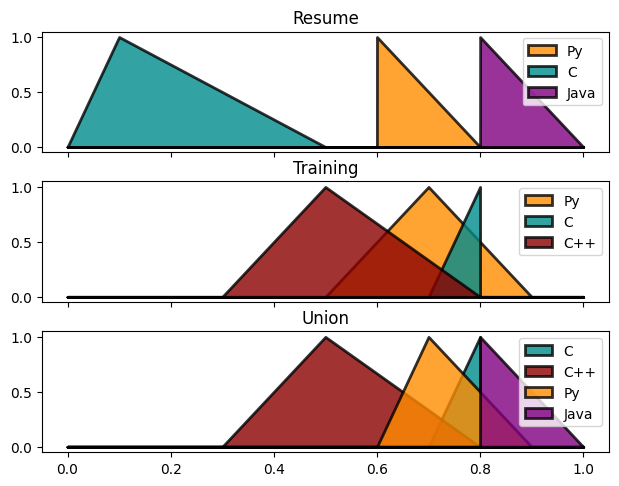

In [12]:
colour = {"Py":"darkorange", "C":"darkcyan", "Java":"purple", "C++":"darkred"}
fig, ax = plt.subplots(3,1, sharex=True, sharey=True)
fig.tight_layout()
for key in resume.keys():
    ax[0].fill_between(X, asymmetricTriangle(*resume[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour[key])
ax[0].legend()
ax[0].set_title("Resume")
for key in trainingAcquire.keys():
    ax[1].fill_between(X, asymmetricTriangle(*trainingAcquire[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour[key])
ax[1].legend()
ax[1].set_title("Training")
for key in newProvider.keys():
    ax[2].fill_between(X, asymmetricTriangle(*newProvider[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour[key])
ax[2].legend()
ax[2].set_title("Union")

#### **Set of eligible Job**
Now that the union and the inclusion is redefined, we can fuzzify the set of eligible job. Originally, this set is defined as:
$$
J(T) = \left\{g\in G, (S^r\not\subseteq S^p) \land (S^r\subseteq S^p\cup A_T)\right\}
$$
Here, the inclusion operator return a Fuzzy I number $a$, whose opposite is $1-a$. We can therefore apply the fuzzy AND. **BUT**, in the preceding work, Łukasiewicz t-norm (AND) was used ; we cannot therefore not change it without changing Fuzzy I framework completely. Fortunately, it does seems to fit well in our context.

Here is a reminder of the Łukasiewicz t-norm:
$$
    X\cap Y \equiv \forall x\in\Omega : \mu_{X\cap Y}(x) = \max\left\{0, \mu_X(x)+\mu_Y(x)-1\right\}
$$

Also, notice that the inclusion and the new representation reversed the charge. We are no longer looking for our skills to include the requirement, but instead our skills to be in the acceptance region of the employer. This is equivalent to the other approach, but completely change the perspective. In our context, the formula therefore become:
$$
    \begin{align*}
        J(T) &= \left\{g\in G, (S^p\not\subseteq S^r) \land (S^p\cup A_T \subseteq S^r)\right\}\\
        &\Leftrightarrow \left\{g\in G, \max\left\{0, (S^p\not\subseteq S^r) + (S^p\cup A_T \subseteq S^r) - 1\right\}\right\}\\
        &\Leftrightarrow \left\{g\in G, \max\left\{0, 1-(S^p\subseteq S^r) + (S^p\cup A_T \subseteq S^r) - 1\right\}\right\}\\
        &\Leftrightarrow \left\{g\in G, \max\left\{0, (S^p\cup S^p_T \subseteq S^r) - (S^p\subseteq S^r)\right\}\right\}
    \end{align*}
$$

As a reminder, because the union cannot decrease the expertises, $(S^p\cup A_T \subseteq S^r) \ge (S^p\subseteq S^r)$. This yield the final formula:

$$
J(T) = \left\{g\in G, (S^p\cup A_T \subseteq S^r) - (S^p\subseteq S^r)\right\}
$$

**Which essentially mean:  *"Inclusion in acceptance region after training minus inclusion within before training."*** By the way, remind that the inclusion return a Fuzzy I number, that is why this formulation work. Note that this is true as long as the aggregation hold this property.

Using the last example, let us try to implements the different inclusion aggregation method.


In [13]:
print(f"Resume: {resume}")
print(f"No requirement training: {trainingAcquire}")
job = {"Py":(0.7,0.6), "C":(0.4,0.4), "C++":(0.3,0.2), "Java":(0.9,0.8)}
print(f"Job: {job}")

Resume: {'Py': (0.6, 0, 0.2), 'C': (0.1, 0.1, 0.4), 'Java': (0.8, 0, 0.2)}
No requirement training: {'Py': (0.7, 0.2, 0.2), 'C': (0.8, 0.1, 0), 'C++': (0.5, 0.2, 0.3)}
Job: {'Py': (0.7, 0.6), 'C': (0.4, 0.4), 'C++': (0.3, 0.2), 'Java': (0.9, 0.8)}


In [14]:
def InclusionDegreeWithAggregation(provided:dict[str, tuple[float,float,float]], 
                                   required:dict[str, tuple[float,float]], 
                                   mode:Literal["mean", "weighted", "confidence", "min","max"]
                                ) -> float:
    
    # Early escape if job without requirements
    if len(required) == 0:
        return 1
    
    # Initialise numerator and denominator
    numerator = 0
    denominator = 0
    if mode == "mean":
        denominator = len(required)
    if mode == "min":
        numerator = 1
    
    # For each skill required
    for key, r in required.items():
        # Compute inclusion degree
        val = InclusionDegree(provided.get(key, (0,0,0)), r)
        
        # Use the designed mode
        if mode == "mean":
            numerator += val
        elif mode == "min" and val < numerator:
            numerator = val
        elif mode == "max" and val > numerator:
            numerator = val
        elif mode == "weighted":
            numerator += val * r[0]
            denominator += r[0]
        elif mode == "confidence":
            weight = (1-(r[0]-r[1])) 
            numerator += val * weight
            denominator += weight
    
    # Already between 0 and 1 for minimum and maximum. No need to normalise
    if mode == "min" or mode == "max":
        return numerator
    
    # Return the aggregation
    return numerator/denominator

Now we can compute $J(T,g)$ for our example:

In [15]:
suat = {key:ProviderSkillExpertiseUnion(resume.get(key), trainingAcquire.get(key)) for key in keys}
meanJtg = InclusionDegreeWithAggregation(suat, job, "mean") - InclusionDegreeWithAggregation(resume, job, "mean")
weightedJtg = InclusionDegreeWithAggregation(suat, job, "weighted") - InclusionDegreeWithAggregation(resume, job, "weighted")
confidenceJtg = InclusionDegreeWithAggregation(suat, job, "confidence") - InclusionDegreeWithAggregation(resume, job, "confidence")
minJtg = InclusionDegreeWithAggregation(suat, job, "min") - InclusionDegreeWithAggregation(resume, job, "min")
maxJtg = InclusionDegreeWithAggregation(suat, job, "max") - InclusionDegreeWithAggregation(resume, job, "max")


print(f"Average J(T,g): {meanJtg}")
print(f"Weighted J(T,g): {weightedJtg}")
print(f"Confidence J(T,g): {confidenceJtg}")
print(f"Min J(T,g): {minJtg}")
print(f"Max J(T,g): {maxJtg}")

Average J(T,g): 0.5708333333333333
Weighted J(T,g): 0.3971014492753622
Confidence J(T,g): 0.581081081081081
Min J(T,g): 0.6666666666666687
Max J(T,g): 0.33333333333333126


Text(0.5, 1.0, 'Requirements')

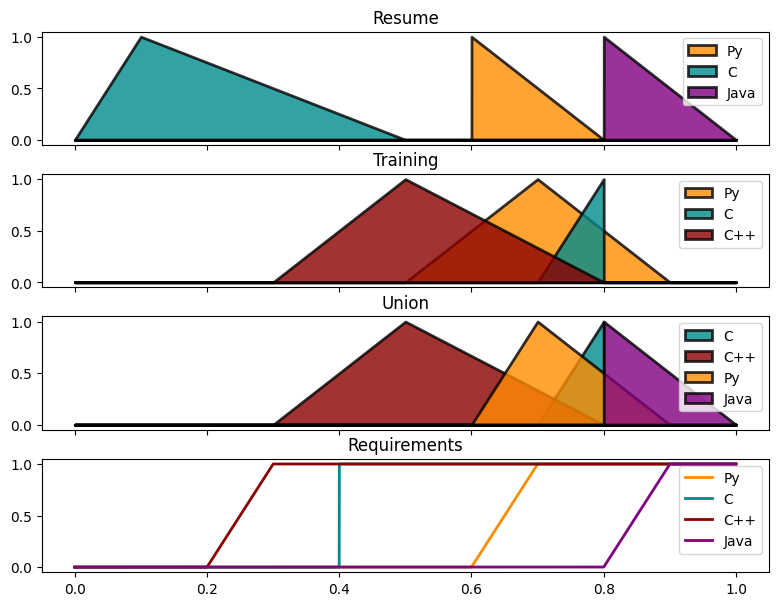

In [16]:
colour = {"Py":"darkorange", "C":"darkcyan", "Java":"purple", "C++":"darkred"}
fig, ax = plt.subplots(4,1, sharex=True, sharey=True, figsize = (8,6))
fig.tight_layout()
for key in resume.keys():
    ax[0].fill_between(X, asymmetricTriangle(*resume[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour[key])
ax[0].legend()
ax[0].set_title("Resume")
for key in trainingAcquire.keys():
    ax[1].fill_between(X, asymmetricTriangle(*trainingAcquire[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour[key])
ax[1].legend()
ax[1].set_title("Training")
for key in newProvider.keys():
    ax[2].fill_between(X, asymmetricTriangle(*newProvider[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour[key])
ax[2].legend()
ax[2].set_title("Union")
for key in job.keys():
    ax[3].plot(X, linearstep(*job[key], X), label = key, lw=2, c = colour[key])
ax[3].legend()
ax[3].set_title("Requirements")

If we had multiple goals, then we would juste add up every $J(T,g)$ to have $\#J(T)$.

#### **Delta**
For the Delta, we want to fuzzify this:
$$
\Delta(S,S') = \begin{cases}
    (s,e_s) & if s\not\in \text{Skills}(S')\\
    (s,\max\{0, e_s-e_{s'}\}) & \text{otherwise}
\end{cases}
$$

Observing the application, $\Delta$ apply in multiple context. Sometimes it is $\Delta(pre(g),S)$ and other times, it is $\Delta(A_T, \Delta(pre(g),S))$. Considering that $pre(g)$ is represented by $S^r$, a linear step, and that $S\cup A_T$ is actually $S^p\cup A^T$ (which is represented of a triangle). We are therefore asking for the gap between a linear step and a triangle, but also between a triangle and an, yet to be discovered, unknown shape.

Unfortunately, it revealed to be quite difficult to provide a sufficiently satisfactory operator. The tested operator or tested idea are (Unordered):
- Distance to maximum expertise (kind of approximation, unstable, does not take confidence into account, pessimistic),
- Distance to confidence expertise (kind of approximation, unstable, does not take full expertise into account, optimistic),
- Convolution (Faithful, but break piecewise linearity and generate complicated shapes, unemployable formula),
- Treats edges as functions and subtract them horizontally (not really what we want),
- Distance to maximal inclusion (may work, but closed formula may be very difficult to infer (exponential number of disjunction case)),
- Symmetry (somehow, work in particular context ; for example if $c_r=e_r$ then symmetry around $\frac{1-e_r}{2}$ seems to work fine...),
- ***Treats Linear step as triangle and subtract vertex with the real triangle*** (approximation, but works fine and account for both confidence and expertise. Simple closed formula).

In our context, we chose the latter option seems to be the one that work the best, even though it does not feel to be the best option (I have multiple doubts, but I cannot say what...). Here is the mathematical formulation depending on whether we use provider and requirement type or both provider type:

***Requirements minus provider (Linear Step minus triangle = Triangle) $\Delta(S^r,S^p)$:***

We have:

- $x_1 = \max\left\{0, e_r-e_{s_i^p}-c_{r{s_i^p}}\right\}$
- $x_2 = \max\left\{0, e_r-e_{s_i^p}\right\}$
- $x_3 = \max\left\{0, e_r-e_{s_i^p}+c_{l{s_i^p}}\right\}$

We set:
- $u_{l_{s_i^\delta}} = \min\{x_1, x_2, x_3\}$
- $u_{r_{s_i^\delta}} = \max\{x_1, x_2, x_3\}$
- $e_{s_i^\delta}$ as the remaining value.

Then, we have:

$$
\Delta(S^r,S^p) = \begin{cases}
    (s^r_i, c_{r_{s^r}}, e_{s^r}-c_{r_{s^r}}, 0) & \text{if } s_i^r\not\in \text{Skills}(S^p)\\
    (s^r_i, e_{s^\delta_i}, e_{s^\delta_i}-u_{l_{s^\delta_i}}, u_{r_{s^\delta_i}}-e_{s^\delta_i}) & \text{otherwise}
\end{cases}
$$

*Note that $s_i^r\not\in \text{Skills}(S^p)$ means that the acceptance region start at $c_r=e_r=0$*

***Provider minus provider (Triangle - Triangle = Triangle) $\Delta(S^{p'},S^p)$:***

We have:

- $x_1 = \max\left\{0, e_{s_i^{p'}}+c_{r_{s_i^{p'}}}-e_{s_i^p}-c_{r_{s_i^p}}\right\}$
- $x_2 = \max\left\{0, e_{s_i^{p'}}-e_{s_i^p}\right\}$
- $x_3 = \max\left\{0, e_{s_i^{p'}}-c_{l_{s_i^{p'}}}-e_{s_i^p}+c_{l_{s_i^p}}\right\}$

We set:
- $u_{l_{s_i^\delta}} = \min\{x_1, x_2, x_3\}$
- $u_{r_{s_i^\delta}} = \max\{x_1, x_2, x_3\}$
- $e_{s_i^\delta}$ as the remaining value.

Then, we have:

$$
\Delta(S^{p'},S^p) = \begin{cases}
    (s^{p'}_i, e_{s^p}, c_{l_{s^p}}, c_{r_{s^p}}) & \text{if } s_i^{p'}\not\in \text{Skills}(S^p)\\
    (s^{p'}_i, e_{s^\delta_i}, e_{s^\delta_i}-u_{l_{s^\delta_i}}, u_{r_{s^\delta_i}}-e_{s^\delta_i}) & \text{otherwise}
\end{cases}
$$

##### **Implementation**

In [17]:
def Delta(
    required:dict[str, tuple[float,float]|tuple[float,float,float]],
    provided:dict[str, tuple[float,float,float]], 
    ) -> dict[str, tuple[float,float,float]]:
    
    returnedDict = {}
    mixed = False
    for key, req_value in required.items():
        if len(req_value) == 2:
            mixed = True
        
        ep, clp, crp = provided.get(key, (None,None,None))
        er = req_value[0]
        if clp is None and mixed:
            returnedDict[key] = (er, er-req_value[1], 0)
            continue
        elif clp is None and not mixed:
            returnedDict[key] = required[key]
        
        x2 = max(0, er-ep)

        if mixed:
            x1 = max(0, er-ep-crp)
            x3 = max(0, req_value[1]-ep+clp)
        else:
            x1 = max(0, er+req_value[2]-ep-crp)
            x3 = max(0, er-req_value[1]-ep+clp)
        
        u1, u2, u3 = sorted((x1,x2,x3))
        returnedDict[key] = (u2, u2-u1, u3-u2)
        
    return returnedDict

In [18]:
Delta(job, resume)

{'Py': (0, 0, 0.09999999999999998),
 'C': (0.30000000000000004, 0.30000000000000004, 0.09999999999999998),
 'C++': (0.3, 0.09999999999999998, 0),
 'Java': (0, 0, 0.09999999999999998)}

In [19]:
job

{'Py': (0.7, 0.6), 'C': (0.4, 0.4), 'C++': (0.3, 0.2), 'Java': (0.9, 0.8)}

In [20]:
resume

{'Py': (0.6, 0, 0.2), 'C': (0.1, 0.1, 0.4), 'Java': (0.8, 0, 0.2)}

In [21]:
trainingAcquire

{'Py': (0.7, 0.2, 0.2), 'C': (0.8, 0.1, 0), 'C++': (0.5, 0.2, 0.3)}

In [22]:
Delta(trainingAcquire, Delta(job, resume))

{'Py': (0.7, 0.2, 0.09999999999999998),
 'C': (0.5, 0.09999999999999998, 0.20000000000000007),
 'C++': (0.2, 0.10000000000000003, 0.3)}

In [23]:
def plotEverything(
    resume:dict[str,tuple[float,float,float]],
    training:dict[str,tuple[float,float,float]],
    job:dict[str,tuple[float,float]],
    colour:dict[str,str] = {"Py":"darkorange", "C":"darkcyan", "Java":"purple", "C++":"darkred"}
) -> None:

    keys = resume.keys() | trainingAcquire.keys()
    union = {key:ProviderSkillExpertiseUnion(resume.get(key), trainingAcquire.get(key)) for key in keys}
    
    fig, ax = plt.subplots(7,1, sharex=True, sharey=True, figsize = (8,10))
    fig.tight_layout()
    for key in resume.keys():
        ax[0].fill_between(X, asymmetricTriangle(*resume[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[0].legend()
    ax[0].set_title("Resume")
    
    for key in training.keys():
        ax[1].fill_between(X, asymmetricTriangle(*training[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[1].legend()
    ax[1].set_title("Training")
    
    for key in job.keys():
        ax[2].fill_between(X, linearstep(*job[key], X), label = key, alpha=0.5, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[2].legend()
    ax[2].set_title("Requirements")
    
    for key in union.keys():
        ax[3].fill_between(X, asymmetricTriangle(*union[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[3].legend()
    ax[3].set_title("Union")
    
    deltaUseful = Delta(job, resume) 
    for key in deltaUseful:
        ax[4].fill_between(X, asymmetricTriangle(*deltaUseful[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[4].legend()
    ax[4].set_title("Delta(job, resume) (Cu)")
    
    deltaMissing = Delta(job, union) 
    for key in deltaMissing:
        ax[5].fill_between(X, asymmetricTriangle(*deltaMissing[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[5].legend()
    ax[5].set_title("Delta(job, resume U training) (Cm)")
    
    deltaUnnecessary = Delta(training, deltaUseful) 
    for key in deltaUnnecessary:
        ax[6].fill_between(X, asymmetricTriangle(*deltaUnnecessary[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[6].legend()
    ax[6].set_title("Delta(training, Delta(job, resume)) (Cun)")
    
    

C:\Users\arnol\AppData\Local\Temp\ipykernel_12144\1411839453.py:18: RuntimeWarning: invalid value encountered in divide
  y[INNER_LEFT] = 1 + (x[INNER_LEFT]-mu)/c1
C:\Users\arnol\AppData\Local\Temp\ipykernel_12144\1411839453.py:19: RuntimeWarning: invalid value encountered in divide
  y[INNER_RIGHT] = 1 - (x[INNER_RIGHT]-mu)/c2


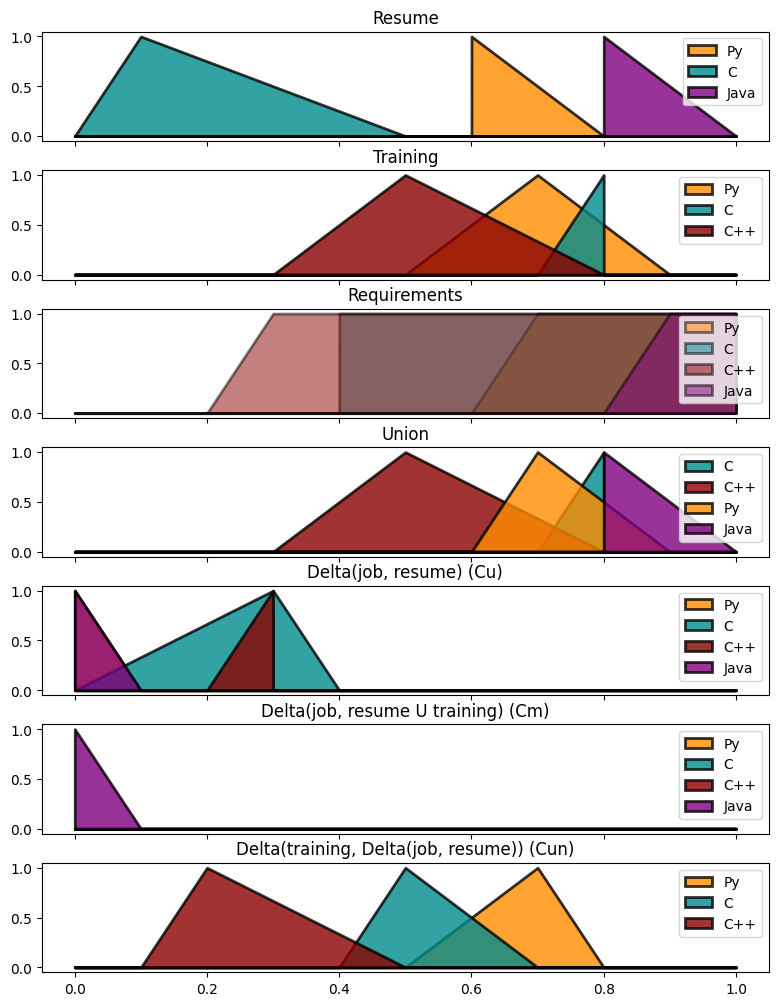

In [24]:
plotEverything(resume, trainingAcquire, job)

#### **Definition of Arithmetics of Triangular Fuzzy Numbers (TFN)**
Again, due to computational reason (plus approximation issue), we will not make usage of any alpha-cuts based methods or discretization method. Instead, we will use the approximation of TFN arithmetic (treated as exact in our context outside extension principle) exposed in *[Syropoulos, A., & Grammenos, T. (2020). A modern introduction to fuzzy mathematics. John Wiley & Sons. (Chapter 3.2.4)]*.

We have the following definition:

Let $A=(\bar{x}_B, \nu_l^A,\nu_r^A)$ and $B=(\bar{x}_B, \nu_l^B, \nu_r^B)$ be two TFN, where $\bar{x}$ is the central value of the triangles and $\nu_l$ (resp. $\nu_r$) the left (resp. right) spread of the triangle. Then the addition, subtraction, division and multiplication and defined and return another triangle:

- **Addition:** $A\ {\bigcirc\hspace{-8.825pt}+}\ B = (\bar{x}^A+\bar{x}^B, \nu_l^A+\nu_l^B, \nu_r^A+\nu_R^B)$
- **Subtraction:** $A\ {\bigcirc\hspace{-8.825pt}-}\ B = (\bar{x}^A-\bar{x}^B, \nu_l^A-\nu_l^B, \nu_r^A-\nu_R^B)$
- **Multiplication:** $A\ {\bigcirc\hspace{-6.25pt}\cdot}\ \ B = (\bar{x}^A\cdot\bar{x}^B, \min\{\nu_l^A\cdot\nu_l^B, \nu_l^A\cdot\nu_r^B, \nu_r^A\cdot\nu_l^B, \nu_r^A\cdot\nu_r^B\}, \max\{\nu_l^A\cdot\nu_l^B, \nu_l^A\cdot\nu_r^B, \nu_r^A\cdot\nu_l^B, \nu_r^A\cdot\nu_r^B\})$
- **Division:** $A\ {\bigcirc\hspace{-8.825pt}\div}\ B = (\bar{x}^A\div\bar{x}^B, \min\{\nu_l^A\div\nu_l^B, \nu_l^A\div\nu_r^B, \nu_r^A\div\nu_l^B, \nu_r^A\div\nu_r^B\}, \max\{\nu_l^A\div\nu_l^B, \nu_l^A\div\nu_r^B, \nu_r^A\div\nu_l^B, \nu_r^A\div\nu_r^B\})$

We can now try yet another implementation:

In [43]:
def sumTFN(tfn1:tuple[float,float,float], tfn2:tuple[float,float,float]) -> tuple[float,float,float]:
    return (tfn1[0]+tfn2[0], tfn1[1]+tfn2[1], tfn1[2]+tfn2[2])

def subTFN(tfn1:tuple[float,float,float], tfn2:tuple[float,float,float]) -> tuple[float,float,float]:
    return (tfn1[0]-tfn2[0], tfn1[1]-tfn2[1], tfn1[2]-tfn2[2])

def mulTFN(tfn1:tuple[float,float,float], tfn2:tuple[float,float,float]) -> tuple[float,float,float]:
    vals = {tfn1[1]*tfn2[1], tfn1[1]*tfn2[2], tfn1[2]*tfn2[1], tfn1[2]*tfn2[2]}
    return (tfn1[0]*tfn2[0], min(vals), max(vals))

def divTFN(tfn1:tuple[float,float,float], tfn2:tuple[float,float,float]) -> tuple[float,float,float]:
    if tfn2[1] == 0 and tfn2[2] == 0:
        return (tfn1[0]/tfn2[0],0,0)
    vals = {tfn1[1]/tfn2[1], tfn1[1]/tfn2[2], tfn1[2]/tfn2[1], tfn1[2]/tfn2[2]}
    return (tfn1[0]/tfn2[0], min(vals), max(vals))

Additionally, we have to describe the sum and multiplication with respects to a scalar. A scalar can be seen as a TFN without spread and centered at the scalar value. Let $A$ be a TFN, let $m\in\mathbb{R}$ be a real scalar. Then we define the addition and multiplication between them as: 

- **Addition between TFN and scalar:** $$A\ {\bigcirc\hspace{-8.825pt}+}\ \ m = (m+\bar{x}^A, \nu_l^A, \nu_r^A)$$
- **Multiplication between TFN and scalar:** Let $u_l^A=\bar{x}^A-\nu_l^A$ and $u_r^A=\bar{x}^A+\nu_r^A$, we have: 
$$A\ {\bigcirc\hspace{-6.25pt}\cdot}\ \ m = (
    m\cdot \bar{x}^A,
    m\cdot \bar{x}^A - \min\{m\cdot u_l^A, m\cdot u_r^A\}, 
    \max\{m\cdot u_l^A, m\cdot u_r^A\} - m\cdot \bar{x}^A
)$$

Notice that the addition and multiplication are commutative.

In [44]:
def scalarSumTFN(tfn:tuple[float,float,float], m:float) -> tuple[float,float,float]:
    return (tfn[0]+m, *tfn[1:])

def scalarMulTFN(tfn:tuple[float,float,float], m:float) -> tuple[float,float,float]:
    x = tfn[0]
    ul = x-tfn[1]
    ur = x+tfn[2]
    mx = m*x
    vals = {m*ul, m*ur}
    
    return (mx, mx-min(vals), max(vals)-mx)

#### **Definition of $C_u(T)$ and $C_u(T,g)$**

The useful component of a training $C_u(T)$ is defined as $C_u(T)= \sum_{g\in G}C_u(T,g)$, where:

$$C_u(T,g) = \sum_{(s,e)\in\Delta(S^r(g),S^p)} e - \sum_{(s',e_{s'})\in\Delta(S^r(g),S^p\cup S^T)} e_{s'}$$

All the requirements were redefined previously, we can therefore implement this right away.

In [45]:
def Union(provider1:dict[str,tuple[float,float,float]], provider2:dict[str,tuple[float,float,float]]) -> dict[str,tuple[float,float,float]]:
    # Make the union of both
    keys = provider1.keys() | provider2.keys()
    return {key:ProviderSkillExpertiseUnion(provider1.get(key), provider2.get(key)) for key in keys}

In [46]:
def CuTg(
    resume:dict[str,tuple[float,float,float]],
    training:dict[str,tuple[float,float,float]],
    job:dict[str,tuple[float,float]]
) -> tuple[float,float,float]:
    
    cutg = (0,0,0)
    for value in Delta(job, resume).values():
        cutg = sumTFN(cutg, value)
    
    for value in Delta(job, Union(resume, training)).values():
        cutg = subTFN(cutg, value)
    
    return cutg

def CuT(
    resume:dict[str,tuple[float,float,float]],
    training:dict[str,tuple[float,float,float]],
    jobs:list[dict[str,tuple[float,float]]]
) -> tuple[float,float,float]:
    cu = (0,0,0)
    for job in jobs:
        cu = sumTFN(cu, CuTg(resume, training, job))
    
    return cu

In [47]:
CuTg(resume, trainingAcquire, job)

(0.6000000000000001, 0.4, 0.19999999999999996)

#### **Definition of $C_m(T)$ and $C_m(T,g)$**

The missing component of a training $C_m(T)$ is defined as $C_m(T)= \sum_{g\in G}C_m(T,g)$, where:

$$C_m(T,g) = \sum_{(s,e_s)\in\Delta(S^r(g),S^p\cup S^T)} e_s$$

All the requirements were redefined previously, we can therefore implement this right away.

In [48]:
def CmTg(
    resume:dict[str,tuple[float,float,float]],
    training:dict[str,tuple[float,float,float]],
    job:dict[str,tuple[float,float]]
) -> tuple[float,float,float]:
    
    cmtg = (0,0,0)
    for value in Delta(job, Union(resume, training)).values():
        cmtg = sumTFN(cmtg, value)
    
    return cmtg

def CmT(
    resume:dict[str,tuple[float,float,float]],
    training:dict[str,tuple[float,float,float]],
    jobs:list[dict[str,tuple[float,float]]]
) -> tuple[float,float,float]:
    cm = (0,0,0)
    for job in jobs:
        cm = sumTFN(cm, CmTg(resume, training, job))
    
    return cm

In [49]:
CmTg(resume, trainingAcquire, job)

(0, 0, 0.09999999999999998)

#### **Definition of $C_{un}(T)$ and $C_{un}(T,g)$**

The unnecessary component of a training $C_{un}(T)$ is defined as $C_{un}(T)= \sum_{g\in G}C_{un}(T,g)$, where:

$$C_{un}(T,g) = \sum_{(s,e_s)\in\Delta(S^T, \Delta(S^r(g),S^p))} e_s$$

All the requirements were redefined previously, we can therefore implement this right away.

In [50]:
def CunTg(
    resume:dict[str,tuple[float,float,float]],
    training:dict[str,tuple[float,float,float]],
    job:dict[str,tuple[float,float]]
) -> tuple[float,float,float]:
    
    cuntg = (0,0,0)
    for value in Delta(training, Delta(job, resume)).values():
        cuntg = sumTFN(cuntg, value)
    
    return cuntg

def CunT(
    resume:dict[str,tuple[float,float,float]],
    training:dict[str,tuple[float,float,float]],
    jobs:list[dict[str,tuple[float,float]]]
) -> tuple[float,float,float]:
    cun = (0,0,0)
    for job in jobs:
        cun = sumTFN(cun, CunTg(resume, training, job))
    
    return cun

In [51]:
CunTg(resume, trainingAcquire, job)

(1.4, 0.4, 0.6000000000000001)

#### **Definition of $U(T)$**

The Utility of a training $U(t)$ is defined as $U(T) = \frac{1}{1+\#G}\left[\#J(T) + \frac{C_u(T)}{C_u(T)+C_m(T)+\frac{C_{un}(T)}{C_{un}(T)+1}}\right]$. Using all the concept we redefined, we can extend this formula to fuzzy set of type II, which will render as a result a TFN.

Here is the implementation:

In [52]:
def U(
    resume:dict[str,tuple[float,float,float]],
    training:dict[str,tuple[float,float,float]],
    jobs:list[dict[str,tuple[float,float,float]]],
    inclusionAggregation:Literal["mean","weighted","confidence","min","max"] = "mean"
) -> tuple[float,float,float]:
    cu = CuT(resume, training, jobs)
    cm = CmT(resume, training, jobs)
    cun = CunT(resume, training, jobs)
    jt = InclusionDegreeWithAggregation(Union(resume, training), job, inclusionAggregation) - InclusionDegreeWithAggregation(resume, job, inclusionAggregation)
    G = len(jobs)
    
    return (
        scalarMulTFN(
            scalarSumTFN(
                divTFN(
                    cu,
                    sumTFN(
                        sumTFN(cu, cm),
                        divTFN(
                            cun,
                            scalarSumTFN(cun, 1)
                        )
                    )
                ),
                jt
            ),
            1/(G+1)
        )
    )

In [53]:
U(resume, trainingAcquire, [job], "mean")

(0.53893779342723, 0.055555555555555525, 0.1875)

##### **Small Experimentation**
Now let's try to really plot everything.

In [78]:
def plotEverything2(
    resume:dict[str,tuple[float,float,float]],
    training:dict[str,tuple[float,float,float]],
    job:dict[str,tuple[float,float]],
    colour:dict[str,str] = {"Py":"darkorange", "C":"darkcyan", "Java":"purple", "C++":"darkred"}
) -> None:
    
    # Compute the Union
    union = Union(resume, training)
    
    # Create the layout
    fig, ax = plt.subplots(4,4, sharex=False, sharey=True, figsize = (14,12))
    fig.tight_layout()
    
    # Plot Resume
    for key in resume.keys():
        if resume[key][1:] == (0,0):
            ax[0,0].plot([resume[key][0], resume[key][0]], [0,1], label=key, c = colour.get(key, "grey"))
        else:
            ax[0,0].fill_between(X, asymmetricTriangle(*resume[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[0,0].legend()
    ax[0,0].set_xlim(-0.025, 1.025)
    ax[0,0].set_title("Resume")
    
    # Plot Training
    for key in training.keys():
        if training[key][1:] == (0,0):
            ax[0,1].plot([training[key][0], training[key][0]], [0,1], label=key, c = colour.get(key, "grey"))
        else:
            ax[0,1].fill_between(X, asymmetricTriangle(*training[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[0,1].legend()
    ax[0,1].set_xlim(-0.025, 1.025)
    ax[0,1].set_title("Training")

    # Union
    for key in union.keys():
        if union[key][1:] == (0,0):
            ax[0,2].plot([union[key][0], union[key][0]], [0,1], label=key, c = colour.get(key, "grey"))
        else:
            ax[0,2].fill_between(X, asymmetricTriangle(*union[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[0,2].legend()
    ax[0,2].set_xlim(-0.025, 1.025)
    ax[0,2].set_title("Resume U Training")
    
    # Plot job Requirements
    for key in job.keys():
        ax[0,3].fill_between(X, linearstep(*job[key], X), label = key, alpha=0.5, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[0,3].legend()
    ax[0,3].set_xlim(-0.025, 1.025)
    ax[0,3].set_title("Job Requirements")
    
    # Delta Cu
    deltaUseful = Delta(job, resume) 
    for key in deltaUseful:
        if deltaUseful[key][1:] == (0,0):
            ax[1,0].plot([deltaUseful[key][0], deltaUseful[key][0]], [0,1], label=key, c = colour.get(key, "grey"))
        else:
            ax[1,0].fill_between(X, asymmetricTriangle(*deltaUseful[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[1,0].legend()
    ax[1,0].set_xlim(-0.025, 1.025)
    ax[1,0].set_title("Δ(Job, Resume) (for Cu)")
    
    # Delta Cm
    deltaMissing = Delta(job, union) 
    for key in deltaMissing:
        if deltaMissing[key][1:] == (0,0):
            ax[1,1].plot([deltaMissing[key][0], deltaMissing[key][0]], [0,1], label=key, c = colour.get(key, "grey"))
        else:
            ax[1,1].fill_between(X, asymmetricTriangle(*deltaMissing[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[1,1].legend()
    ax[1,1].set_xlim(-0.025, 1.025)
    ax[1,1].set_title("Δ(Job, Resume U Training) (for Cm)")
    
    # Delta Cun
    deltaUnnecessary = Delta(training, deltaUseful) 
    for key in deltaUnnecessary:
        if deltaUnnecessary[key][1:] == (0,0):
            ax[1,2].plot([deltaUnnecessary[key][0], deltaUnnecessary[key][0]], [0,1], label=key, c = colour.get(key, "grey"))
        else:
            ax[1,2].fill_between(X, asymmetricTriangle(*deltaUnnecessary[key], X), label = key, alpha=0.8, lw=2, ec="black", fc = colour.get(key, "grey"))
    ax[1,2].legend()
    ax[1,2].set_xlim(-0.025, 1.025)
    ax[1,2].set_title("Δ(Training, Δ(Job, Resume)) (for Cun)")
    
    # Additional Informations about J(T)
    jtmean = InclusionDegreeWithAggregation(Union(resume, training), job, "mean") - InclusionDegreeWithAggregation(resume, job, "mean")
    jtmin = InclusionDegreeWithAggregation(Union(resume, training), job, "min") - InclusionDegreeWithAggregation(resume, job, "min")
    jtmax = InclusionDegreeWithAggregation(Union(resume, training), job, "max") - InclusionDegreeWithAggregation(resume, job, "max")
    jtweight = InclusionDegreeWithAggregation(Union(resume, training), job, "weighted") - InclusionDegreeWithAggregation(resume, job, "weighted")
    jtconf = InclusionDegreeWithAggregation(Union(resume, training), job, "confidence") - InclusionDegreeWithAggregation(resume, job, "confidence")

    ax[1,3].text(0.02, 0.98, f"#J(T) mean inc.: {jtmean:.4f}")
    ax[1,3].text(0.02, 0.92, f"#J(T) min inc.: {jtmin:.4f}")
    ax[1,3].text(0.02, 0.86, f"#J(T) max inc.: {jtmax:.4f}")
    ax[1,3].text(0.02, 0.80, f"#J(T) weight inc.: {jtweight:.4f}")
    ax[1,3].text(0.02, 0.74, f"#J(T) conf inc.: {jtconf:.4f}")
    
    ax[1,3].set_axis_off()
    
    # Cu
    cu = CuTg(resume, training, job)
    Xcu = np.linspace(min(0, cu[0]+cu[2])-0.025, max(1, cu[0]+cu[2])+0.025, 10**4)
    ax[2,0].set_xlim(Xcu[0], Xcu[10**4-1])
    if cu[1:] == (0,0):
        ax[2,0].plot([cu[0], cu[0]], [0,1], label = "Cu(T)", lw=2, c="black")
    else:
        ax[2,0].fill_between(Xcu, asymmetricTriangle(*cu, Xcu), label = "Cu(T)", alpha=0.8, lw=2, ec="black", fc = "grey")
    ax[2,0].scatter([0], [0], alpha=0, label=f"{cu[0]:.4f},\n{cu[1]:.4f},\n{cu[2]:.4f}")
    ax[2,0].legend()
    ax[2,0].set_title("Cu(T)")
    
    # Cm
    cm = CmTg(resume, training, job)
    Xcm = np.linspace(min(0, cm[0]+cm[2])-0.025, max(1, cm[0]+cm[2])+0.025, 10**4)
    ax[2,1].set_xlim(Xcm[0], Xcm[10**4-1])
    if cm[1:] == (0,0):
        ax[2,1].plot([cm[0], cm[0]], [0,1], label = "Cm(T)", lw=2, c="black")
    else:
        ax[2,1].fill_between(Xcm, asymmetricTriangle(*cm, Xcm), label = "Cm(T)", alpha=0.8, lw=2, ec="black", fc = "grey")
    ax[2,1].scatter([0], [0], alpha=0, label=f"{cm[0]:.4f},\n{cm[1]:.4f},\n{cm[2]:.4f}")
    ax[2,1].legend()
    ax[2,1].set_title("Cm(T)")
    
    # Cun
    cun = CunTg(resume, training, job)
    Xcun = np.linspace(min(0, cun[0]+cun[2])-0.025, max(1, cun[0]+cun[2])+0.025, 10**4)
    ax[2,2].set_xlim(Xcun[0], Xcun[10**4-1])
    if cun[1:] == (0,0):
        ax[2,2].plot([cun[0], cun[0]], [0,1], label = "Cun(T)", lw=2, c="black")
    else:
        ax[2,2].fill_between(Xcun, asymmetricTriangle(*cun, Xcun), label = "Cun(T)", alpha=0.8, lw=2, ec="black", fc = "grey")
    ax[2,2].scatter([0], [0], alpha=0, label=f"{cun[0]:.4f},\n{cun[1]:.4f},\n{cun[2]:.4f}")
    ax[2,2].legend()
    ax[2,2].set_title("Cun(T)")
    
    # Utility with mean inclusion
    meanU = U(resume, training, [job], "mean")
    XmeanU = np.linspace(min(0, meanU[0]+meanU[2])-0.025, max(1, meanU[0]+meanU[2])+0.025, 10**4)
    ax[2,3].set_xlim(XmeanU[0], XmeanU[10**4-1])
    if meanU[1:] == (0,0):
        ax[2,3].plot([meanU[0], meanU[0]], [0,1], label = "U(T)", lw=2, c="black")
    else:
        ax[2,3].fill_between(XmeanU, asymmetricTriangle(*meanU, XmeanU), label = "U(T)", alpha=0.8, lw=2, ec="black", fc = "grey")
    ax[2,3].scatter([0], [0], alpha=0, label=f"{meanU[0]:.4f},\n{meanU[1]:.4f},\n{meanU[2]:.4f}")
    ax[2,3].legend()
    ax[2,3].set_title("Utility w/ mean Aggregation")
    
    # Utility with min inclusion
    minU = U(resume, training, [job], "min")
    XminU = np.linspace(min(0, minU[0]+minU[2])-0.025, max(1, minU[0]+minU[2])+0.025, 10**4)
    ax[3,0].set_xlim(XminU[0], XminU[10**4-1])
    if minU[1:] == (0,0):
        ax[3,0].plot([minU[0], minU[0]], [0,1], label = "U(T)", lw=2, c="black")
    else:
        ax[3,0].fill_between(XminU, asymmetricTriangle(*minU, XminU), label = "U(T)", alpha=0.8, lw=2, ec="black", fc = "grey")
    ax[3,0].scatter([0], [0], alpha=0, label=f"{minU[0]:.4f},\n{minU[1]:.4f},\n{minU[2]:.4f}")
    ax[3,0].legend()
    ax[3,0].set_title("Utility w/ min Aggregation")
    
    # Utility with max inclusion
    maxU = U(resume, training, [job], "max")
    XmaxU = np.linspace(min(0, maxU[0]+maxU[2])-0.025, max(1, maxU[0]+maxU[2])+0.025, 10**4)
    ax[3,1].set_xlim(XmaxU[0], XmaxU[10**4-1])
    if maxU[1:] == (0,0):
        ax[3,1].plot([maxU[0], maxU[0]], [0,1], label = "U(T)", lw=2, c="black")
    else:
        ax[3,1].fill_between(XmaxU, asymmetricTriangle(*maxU, XmaxU), label = "U(T)", alpha=0.8, lw=2, ec="black", fc = "grey")
    ax[3,1].scatter([0], [0], alpha=0, label=f"{maxU[0]:.4f},\n{maxU[1]:.4f},\n{maxU[2]:.4f}")
    ax[3,1].legend()
    ax[3,1].set_title("Utility w/ max Aggregation")
    
    # Utility with weighted inclusion
    weightU = U(resume, training, [job], "weighted")
    XweightU = np.linspace(min(0, weightU[0]+weightU[2])-0.025, max(1, weightU[0]+weightU[2])+0.025, 10**4)
    ax[3,2].set_xlim(XweightU[0], XweightU[10**4-1])
    if weightU[1:] == (0,0):
        ax[3,2].plot([weightU[0], weightU[0]], [0,1], label = "U(T)", lw=2, c="black")
    else:
        ax[3,2].fill_between(XweightU, asymmetricTriangle(*weightU, XweightU), label = "U(T)", alpha=0.8, lw=2, ec="black", fc = "grey")
    ax[3,2].scatter([0], [0], alpha=0, label=f"{weightU[0]:.4f},\n{weightU[1]:.4f},\n{weightU[2]:.4f}")
    ax[3,2].legend()
    ax[3,2].set_title("Utility w/ weighted Aggregation")
    
    # Utility with confidence inclusion
    confU = U(resume, training, [job], "confidence")
    XconfU = np.linspace(min(0, confU[0]+confU[2])-0.025, max(1, confU[0]+confU[2])+0.025, 10**4)
    ax[3,3].set_xlim(XconfU[0], XconfU[10**4-1])
    if confU[1:] == (0,0):
        ax[3,3].plot([confU[0], confU[0]], [0,1], label = "U(T)", lw=2, c="black")
    else:
        ax[3,3].fill_between(XconfU, asymmetricTriangle(*confU, XconfU), label = "U(T)", alpha=0.8, lw=2, ec="black", fc = "grey")
    ax[3,3].scatter([0], [0], alpha=0, label=f"{confU[0]:.4f},\n{confU[1]:.4f},\n{confU[2]:.4f}")
    ax[3,3].legend()
    ax[3,3].set_title("Utility w/ confidence Aggregation")
    

C:\Users\arnol\AppData\Local\Temp\ipykernel_12144\1411839453.py:18: RuntimeWarning: invalid value encountered in divide
  y[INNER_LEFT] = 1 + (x[INNER_LEFT]-mu)/c1


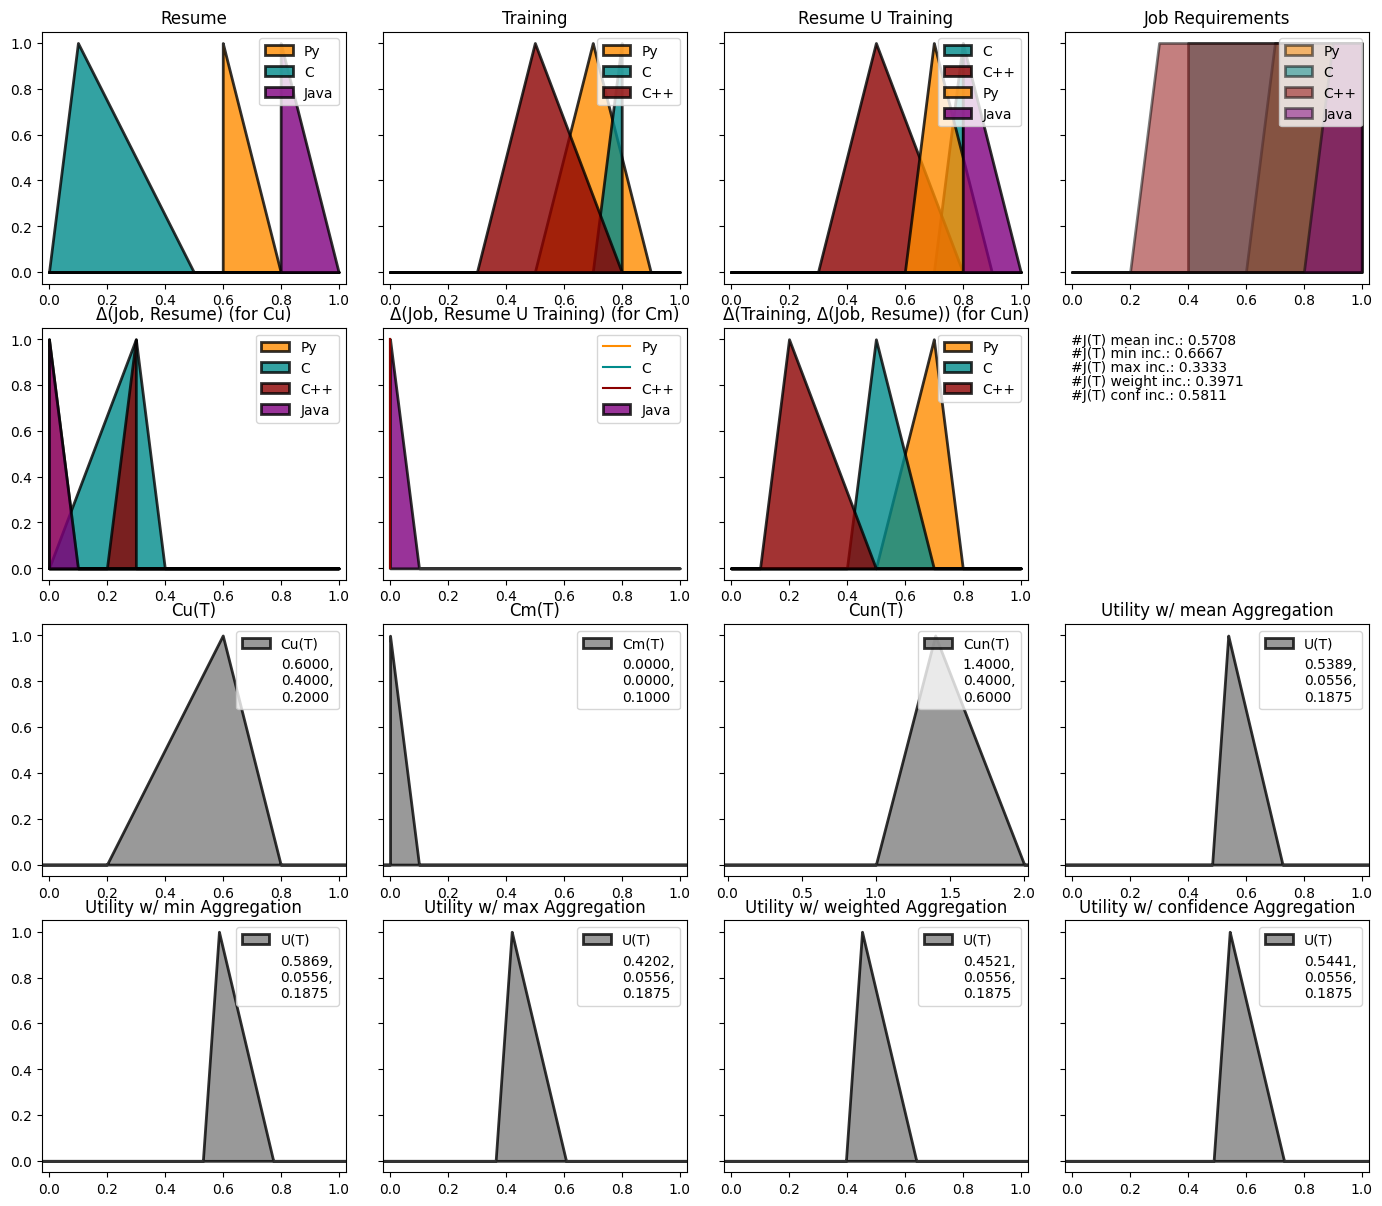

In [79]:
plotEverything2(resume, trainingAcquire, job)

#### **Extension check**
What about crisp? Can we really say we have a proper extension (encapsulate Fuzzy I without changes in results)?

Let us try out, by creating a Fuzzy I equivalent.

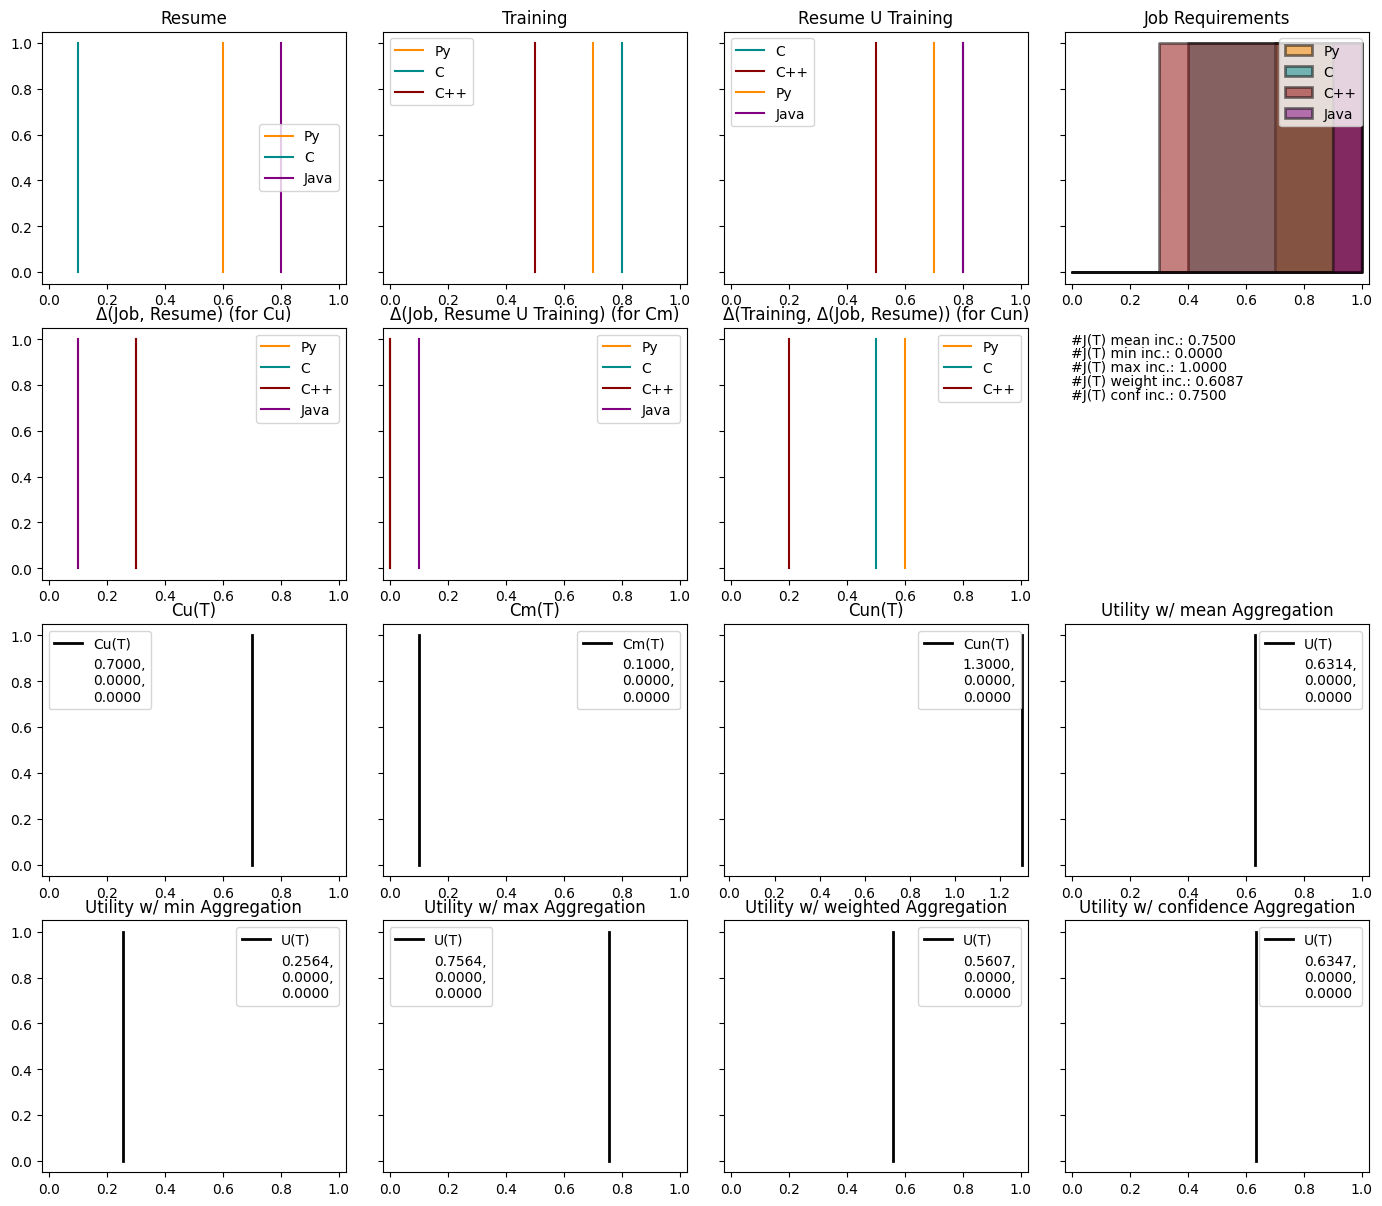

In [80]:
trainingFuzzyI = {"Py":(0.7,0,0), "C":(0.8,0,0), "C++":(0.5,0,0)}
jobFuzzyI = {"Py":(0.7,0.7), "C":(0.4,0.4), "C++":(0.3,0.3), "Java":(0.9,0.9)}
resumeFuzzyI = {"Py":(0.6,0,0), "C":(0.1,0,0), "Java":(0.8,0,0)}
plotEverything2(resumeFuzzyI, trainingFuzzyI, jobFuzzyI)

Now we will compute by hand, what we would have got if we used the original framework.

In [98]:
print(f"""
Fuzzy I Resume (S): {resumeFuzzyI}
Fuzzy I Training (At): {trainingFuzzyI}
Fuzzy I Job (pre(g)): {jobFuzzyI}
---
Fuzzy II Union(S, At): {Union(resumeFuzzyI, trainingFuzzyI)}
Fuzzy II Delta(pre(g), S): {Delta(jobFuzzyI, resumeFuzzyI)}
Fuzzy II Delta(pre(g), Union(S, At)): {Delta(jobFuzzyI, Union(resumeFuzzyI, trainingFuzzyI))}
Fuzzy II Delta(At, Delta(pre(g), S)): {Delta(trainingFuzzyI, Delta(jobFuzzyI, resumeFuzzyI))}
---
Fuzzy II Cu(T): {CuTg(resumeFuzzyI, trainingFuzzyI, jobFuzzyI)}
Fuzzy II Cm(T): {CmTg(resumeFuzzyI, trainingFuzzyI, jobFuzzyI)}
Fuzzy II Cun(T): {CunTg(resumeFuzzyI, trainingFuzzyI, jobFuzzyI)}
----
Fuzzy II #J(T) [min]: {InclusionDegreeWithAggregation(Union(resumeFuzzyI, trainingFuzzyI), jobFuzzyI, 'min') - InclusionDegreeWithAggregation(resumeFuzzyI, jobFuzzyI, 'min')}
Fuzzy II #J(T) [max]: {InclusionDegreeWithAggregation(Union(resumeFuzzyI, trainingFuzzyI), jobFuzzyI, 'max') - InclusionDegreeWithAggregation(resumeFuzzyI, jobFuzzyI, 'max')}
Fuzzy II #J(T) [mean]: {InclusionDegreeWithAggregation(Union(resumeFuzzyI, trainingFuzzyI), jobFuzzyI, 'mean') - InclusionDegreeWithAggregation(resumeFuzzyI, jobFuzzyI, 'mean')}
Fuzzy II #J(T) [weighted]: {InclusionDegreeWithAggregation(Union(resumeFuzzyI, trainingFuzzyI), jobFuzzyI, 'weighted') - InclusionDegreeWithAggregation(resumeFuzzyI, jobFuzzyI, 'weighted')}
Fuzzy II #J(T) [confidence]: {InclusionDegreeWithAggregation(Union(resumeFuzzyI, trainingFuzzyI), jobFuzzyI, 'confidence') - InclusionDegreeWithAggregation(resumeFuzzyI, jobFuzzyI, 'confidence')}
----
Fuzzy II U(T) [min]: {U(resumeFuzzyI, trainingFuzzyI, [jobFuzzyI], 'min')}
Fuzzy II U(T) [max]: {U(resumeFuzzyI, trainingFuzzyI, [jobFuzzyI], 'max')}
Fuzzy II U(T) [mean]: {U(resumeFuzzyI, trainingFuzzyI, [jobFuzzyI], 'mean')}
Fuzzy II U(T) [weighted]: {U(resumeFuzzyI, trainingFuzzyI, [jobFuzzyI], 'weighted')}
Fuzzy II U(T) [confidence]: {U(resumeFuzzyI, trainingFuzzyI, [jobFuzzyI], 'confidence')}
""")



Fuzzy I Resume (S): {'Py': (0.6, 0, 0), 'C': (0.1, 0, 0), 'Java': (0.8, 0, 0)}
Fuzzy I Training (At): {'Py': (0.7, 0, 0), 'C': (0.8, 0, 0), 'C++': (0.5, 0, 0)}
Fuzzy I Job (pre(g)): {'Py': (0.7, 0.7), 'C': (0.4, 0.4), 'C++': (0.3, 0.3), 'Java': (0.9, 0.9)}
---
Fuzzy II Union(S, At): {'C': (0.8, 0.0, 0.0), 'C++': (0.5, 0, 0), 'Py': (0.7, 0.0, 0.0), 'Java': (0.8, 0, 0)}
Fuzzy II Delta(pre(g), S): {'Py': (0.09999999999999998, 0.0, 0.0), 'C': (0.30000000000000004, 0.0, 0.0), 'C++': (0.3, 0.0, 0), 'Java': (0.09999999999999998, 0.0, 0.0)}
Fuzzy II Delta(pre(g), Union(S, At)): {'Py': (0, 0, 0), 'C': (0, 0, 0), 'C++': (0, 0, 0), 'Java': (0.09999999999999998, 0.0, 0.0)}
Fuzzy II Delta(At, Delta(pre(g), S)): {'Py': (0.6, 0.0, 0.0), 'C': (0.5, 0.0, 0.0), 'C++': (0.2, 0.0, 0.0)}
---
Fuzzy II Cu(T): (0.7, 0.0, 0.0)
Fuzzy II Cm(T): (0.09999999999999998, 0.0, 0.0)
Fuzzy II Cun(T): (1.3, 0.0, 0.0)
----
Fuzzy II #J(T) [min]: 0
Fuzzy II #J(T) [max]: 1
Fuzzy II #J(T) [mean]: 0.75
Fuzzy II #J(T) [weighte

Now we can make the computation with Fuzzy I:
|component|rowID|Py|C|C++|Java|
|---------|-----|--|-|---|----|
|$S$|(1)|0.6|0.1|$\cdots$|0.8|
|$A_T$|(2)|0.7|0.8|0.5|$\cdots$|
|$S\cup A_T$|(3), max[(1),(2)]|0.7|0.8|0.5|0.8|
|$pre(g)$|(4)|0.7|0.4|0.3|0.9|
|---------|-----|--|-|---|----|
|$\Delta(pre(g),S)$|(5) max[0, (4)-(1)]|0.1|0.3|0.3|0.1|
|$\Delta(pre(g),S\cup A_T)$|(6) max[0, (4)-(3)]|0|0|0|0.1|
|$\Delta(A_T,\Delta(pre(g),S))$|(7) max[0, (2)-(5)]|0.6|0.5|0.2|0|
|---------|-----|--|-|---|----|
|$C_m(T)$|(8) sum[(6)]|0.1|
|$C_u(T)$|(9) [sum[(5)]-(8)]|0.7|
|$C_{un}(T)$|(10) sum[(7)]|1.3|
|$\#J(T)$|(11) |0|
|$\#G$|(12) |1|
|---------|-----|--|-|---|----|
|$U(T)$|(13) [1/[1+(12)]*[(11)+[(9)/[(9)+(8)+[(10)/[(10)+1]]]]]]|**0.25637**|







Here, we observe that all the components (up tp $\#J(T)$) are identical whether we use the fuzzy I or fuzzy II framework. This signify that, on a random instance, the formula was extended properly (this still need formal proofs).

But for $\#J(T)$, we have different possible aggregation. With this example, we see that $\min$ is the only possibility for extension. It is not proven that $\min$ leads to extension, but it is the only discovered possibility if it is the case.

But now, we want proofs!

#### **Extension check proofs**
We have to prove that any encodable situation in the Fuzzy I system can be encoded equivalently using. So we will prove that every component yield to equivalent results by considering depleted triangle and full step ramps.

This way, a user expertise of 0.87 would be represented by the triangle (0.87,0,0), while a required expertise of 0.7 would be represented as the ramp (0.7,0.7).

**START**

Let $e^p_s$ (resp. $e^r_s$) be an arbitrary provider (resp. requirement) expertise for a skill $s$, then we start effectively with the following axioms:

- **(Axiom 1) Depleted Triangle:** $(s, e^p_s)\equiv (s, e^p_s, 0, 0)$
- **(Axiom 2) Depleted Ramp:** $(s, e^r_s)\equiv (e^r_s, e^r_s)$
- **(Axiom 3) No Provided Expertise:** $s\not\in\text{Skills}(S) \equiv s \Leftrightarrow (s,0)$
- **(Lemma 1) Provider Skill-Expertise Set equivalence:** Let $S_I=\{(s^p_0, e^p_{s_0}), \cdots, (s^p_i, e^p_{s_i}), \cdots, (s^p_n, e^p_{s_n})\}$ be a provider Skill-Expertise Set (Fuzzy I) and $S_{II}=\{(s^p_0, e^p_{s_0},0,0), \cdots, (s^p_i, e^p_{s_i},0,0), \cdots, (s^p_n, e^p_{s_n},0,0)\}$ a provider Skill-Expertise Set (Fuzzy II), then $S_I\equiv S_{II}$.
- **(Lemma 2) Requirement Skill-Expertise Set equivalence:** Let $S_I=\{(s^r_0, e^r_{s_0}), \cdots, (s^r_i, e^r_{s_i}), \cdots, (s^r_n, e^r_{s_n})\}$ be a provider Skill-Expertise Set (Fuzzy I) and $S_{II}=\{(s^p_0, e^p_{s_0}, e^p_{s_0}), \cdots, (s^p_i, e^p_{s_i}, e^p_{s_i}), \cdots, (s^p_n, e^p_{s_n}, e^p_{s_n})\}$ a provider Skill-Expertise Set (Fuzzy II), then $S_I\equiv S_{II}$.

Notice that **Lemma 1** and **Lemma 2** follows directly from **Axiom 1** and **Axiom 2**. We will therefore not make a proof for them.

**Hypothesis: We will only work with Fuzzy II tuples satisfying *Axiom 1* and *Axiom 2*.**

We will prove now that the operations made on the tuples yields the same results as the one on the scalar expertise.

##### **Proof for Union**
Let us denote the initial Union operator as:
$$
\text{Union}_I(S^p, S^{p'}) = \begin{cases}
    (s,\max(e_s^p, e_s^{p'})) & \text{if}\ s\in\text{Skills}(S^{p'})\\
    (s, e_s^p) & \text{if}\ s\not\in\text{Skills}(S^{p'})\\
    (s', e_{s'}^{p'}) & \text{if}\ s'\not\in\text{Skills}(S^p)\\
\end{cases}
$$

The new one can be denoted:
$$
\text{Union}_{II}(S^p, S^{p'}) = \begin{cases}
    \left(s, z, z-\max(e_s^p-c_{l_{s^p}}, e_s^{p'}-c_{l_{s^{p'}}}), \max(e_s^p-c_{r_{s^p}}, e_s^{p'}+c_{r_{s^{p'}}}) - z\right) & \text{if}\ s\in\text{Skills}(S^{p'})\\
    (s, e_s^p, c_{l_{s^p}}, c_{r_{s^p}}) & \text{if}\ s\not\in\text{Skills}(S^{p'})\\
    (s, e_s^{p'}, c_{l_{s^{p'}}}, c_{r_{s^{p'}}}) & \text{if}\ s\not\in\text{Skills}(S^p)
\end{cases}
$$

where $z = \max(e_s^p, e_s^{p'})$, $c_{l_{s^p}}$ the left confidence and $c_{r_{s^p}}$ the right confidence of the triangle.

Notice that working with depleted triangle make $c_{l_{s^p}} = c_{r_{s^p}} = 0$. This simplify the new union formula:
$$
\text{Union}_{II}(S^p, S^{p'}) = \begin{cases}
    \left(s, \max(e_s^p, e_s^{p'}), 0, 0\right) & \text{if}\ s\in\text{Skills}(S^{p'})\\
    (s, e_s^p, 0, 0) & \text{if}\ s\not\in\text{Skills}(S^{p'})\\
    (s, e_s^{p'}, 0, 0) & \text{if}\ s\not\in\text{Skills}(S^p)
\end{cases}
$$

The results is a set having the property described in **Lemma 1**, moreover, each cases can be rewritten using **Axiom 1**. In this perspective, it is clear that $\boxed{\text{Union}_I\equiv\text{Union}_{II}}\qquad\blacksquare$


##### **Proof for Inclusion**
In the initial framework $S^p\subseteq S^r \equiv \forall (s, e^r_s)\in S^r : s\in\text{Skills}(S^p)\land S^p(s)\ge S^r(s)$. We will denote this inclusion as $\subseteq_I$.

In the new Fuzzy II context, the inclusion $\subseteq_{II}$ is defined as the minimum aggregation of Inclusion Degrees $I(S^p(s), S^p(r))= \frac{\int_{-\infty}^\infty \min\left\{S^p(s), S^r(s)\right\}\text{d}x}{\int_{-\infty}^\infty S^p(s)\text{d}x}$. In case where the indefinite form $\frac{X}{0}$ appears, then the results is set to the height of the intersection between the two fuzzy sets.

Considering, depleted ramps and triangles, we have two cases for a skill $s$:
- $e_s^p\ge e_s^r$, which means that the expertise of the provider is greater or equal to the required expertise. In this case, the highest point of the intersection between the depleted ramp and triangle is 1 (because the triangle arrives after the step).
- $e_s^r<e_s^r$, which signify that the provided expertise is insufficient. In this case, the highest point of the intersection is 0 (because the step did not happen yet).

Doing this for every expertise in $S^r$ and taking the minimum ensure that every required skill are taken into consideration. Moreover, if any skill does not meet the requirement, then, the minimum becomes 0 by default, thus resulting in no inclusion (exactly like in fuzzy case.) Plus, using depleted triangle and ramp also mean that the inclusion degree is guaranteed to be either 1 or 0. Therefore, the condition for $S^p\subseteq_{II} S^r$ to be 1, where $S^p$ is following **Lemma 1** and $S^r$ **Lemma 2**, is becoming exactly the one for $\subseteq_{I}$.

As a conclusion: $\boxed{\subseteq_I \equiv \subseteq_{II}}\qquad\blacksquare$

##### **Proof for $\#J(T)$**
In the original framework, $J_I(T)=\left\{g\in G, (S^r_g\not\subseteq_I S^p) \land (S^r_g\subseteq_I S^p\cup S^p_T)\right\}$. This is basically the set of goals whose requirements are not met before a training, but are after.

In the new formulation, we have $J_{II}(T) = \left\{g\in G, (S^p\cup A_T \subseteq_{II} S^r_g) - (S^p\subseteq_{II} S^r_g)\right\}$

Considering minimum aggregation, the results of the inclusion between a depleted triangle and a depleted ramp is either 0 or 1 (**Proof for Inclusion**). Moreover, participating to a training cannot decrease the expertise of someone (see *Union*), therefore the sum of expertise after training is greater or equal to the one before.

We have $(S^p\cup A_T\subseteq_{II} S^r_g) \ge (S^p\subseteq_{II} S^r_g)$. In this sense, if $J_{II}(T)(g) = 1$ then the goal was not reachable before training (the inclusion is a correct extension), but is after training. Consequently, the goal is placed in $J_{II}(T)$ with truth value 1. 

If $J_{II}(T)(g) = 0$, then the only solutions is either the training was already accessible (1 of inclusion before and after) or never was (0 for both). Since we work with depleted fuzzy set, these are the unique solution after inclusion. In both case, they are added in the set with truth value 0.

Notice that is the same definition as the original framework. In this sense $J_I(T)\equiv_{\text{def}} J_{II}(T)$.

The fuzzy cardinality $\#J_{II}(T)$ is the sum of truth value of all its elements, which is actually the number of one in the set. The cardinality $\#J_I(T)$ is the size of the set ; since we exclude 0, it is the number of 1 again. Since we proved equivalence by definition, the number of one is the same in both set. 

Therefore $\boxed{\#J_I(T)=\#J_{II}(T)}\qquad\blacksquare$


##### **Proof for Fuzzy Arithmetics**
In the old fuzzy I context, the fuzzy arithmetics was actually the crisp one with real values. In this sense, nothing changed. But with type II fuzzy sets, we are now working with triangles. We therefore need to prove that depleted triangles leads to classical crisp arithmetics.

Here is the of the arithmetics:

- **Addition:** $S^p(s)\ {\bigcirc\hspace{-8.825pt}+}\ S^{p'}(s) = (e_s^p+e_s^{p'}, \nu_l^{p_s}+\nu_l^{p'_s}, \nu_r^{p_s}+\nu_r^{p'_s})$
- **Subtraction:** $S^p(s)\ {\bigcirc\hspace{-8.825pt}-}\ S^{p'}(s) = (e_s^p-e_s^{p'}, \nu_l^{p_s}-\nu_l^{p'_s}, \nu_r^{p_s}-\nu_R^{p'_s})$
- **Multiplication:** $S^p(s)\ {\bigcirc\hspace{-6.25pt}\cdot}\ \ S^{p'}(s) = (e_s^p\cdot e_s^{p'}, \min\{\nu_l^{p_s}\cdot\nu_l^{p'_s}, \nu_l^{p_s}\cdot\nu_r^{p'_s}, \nu_r^{p_s}\cdot\nu_l^{p'_s}, \nu_r^{p_s}\cdot\nu_r^{p'_s}\}, \max\{\nu_l^{p_s}\cdot\nu_l^{p'_s}, \nu_l^{p_s}\cdot\nu_r^{p'_s}, \nu_r^{p_s}\cdot\nu_l^{p'_s}, \nu_r^{p_s}\cdot\nu_r^{p'_s}\})$
- **Division:** $S^p(s)\ {\bigcirc\hspace{-8.825pt}\div}\ S^{p'}(s) = (e_s^p\div e_s^{p'}, \min\{\nu_l^{p_s}\div\nu_l^{p'_s}, \nu_l^{p_s}\div\nu_r^{p'_s}, \nu_r^{p_s}\div\nu_l^{p'_s}, \nu_r^{p_s}\div\nu_r^{p'_s}\}, \max\{\nu_l^{p_s}\div\nu_l^{p'_s}, \nu_l^{p_s}\div\nu_r^{p'_s}, \nu_r^{p_s}\div\nu_l^{p'_s}, \nu_r^{p_s}\div\nu_r^{p'_s}\})$

With $\nu_l$ (resp. $\nu_r$) be the left (resp. right) confidence of the triangle. We remind that with depleted triangles, $\nu_l^\cdot=\nu_r^\cdot=0$. We can therefore simplify everything.

- **Addition:** $S^p(s)\ {\bigcirc\hspace{-8.825pt}+}\ S^{p'}(s) = (e_s^p+e_s^{p'}, 0, 0)$
- **Subtraction:** $S^p(s)\ {\bigcirc\hspace{-8.825pt}-}\ S^{p'}(s) = (e_s^p-e_s^{p'}, 0, 0)$
- **Multiplication:** $S^p(s)\ {\bigcirc\hspace{-6.25pt}\cdot}\ \ S^{p'}(s) = (e_s^p\cdot e_s^{p'}, 0, 0)$

Which is equivalent to crisp arithmetics using **Axiom 1**.

For division, a special case was built in case of division by 0 due to $\nu_r^{p'_s}=\nu_l^{p'_s}=0$ (that would happen here). The case stipulate that in such scenario, the result of the $\max$ and the $\min$ would be 0. This effectively force everything back to crisp arithmetics with:
- **Division:** $S^p(s)\ {\bigcirc\hspace{-8.825pt}\div}\ S^{p'}(s) = (e_s^p\div e_s^{p'}, 0, 0)$

This is indeed crisp arithmetics, therefore, the multiplication, division, addition and subtraction between triangular is a right extension.

For the special cases with scalars:
- **Addition between TFN and scalar:** $$S^p(s)\ {\bigcirc\hspace{-8.825pt}+}\ \ m = (m+e_s^p, \nu_l^{p_s}, \nu_r^{p_s})$$
- **Multiplication between TFN and scalar:** Let $u_l^{p_s}=e_s^p-\nu_l^{p_s}$ and $u_r^{p_s}=e_s^p+\nu_r^{p_s}$, we have: 
$$S^p(s)\ {\bigcirc\hspace{-6.25pt}\cdot}\ \ m = (
    m\cdot e_s^p,
    m\cdot e_s^p - \min\{m\cdot u_l^{p_s}, m\cdot u_r^{p_s}\}, 
    \max\{m\cdot u_l^{p_s}, m\cdot u_r^{p_s}\} - m\cdot e_s^p
)
$$

Here again this simplify using depleted triangle:
- **Addition between TFN and scalar:** $$S^p(s)\ {\bigcirc\hspace{-8.825pt}+}\ \ m = (m+e_s^p, 0, 0)$$
- **Multiplication between TFN and scalar:**
$$S^p(s)\ {\bigcirc\hspace{-6.25pt}\cdot}\ \ m = (
    m\cdot e_s^p,
    0, 
    0
)
$$

This is the normal multiplication and addition if we use **Axiom 1**, as intended. $\qquad\blacksquare$

##### **Proof for Delta**
Here, we have three Delta to prove to be equivalent: $\Delta(S^r, S^p)$, $\Delta(S^r, S^p\cup S^p_T)$ and $\Delta(S^p_T, \Delta(S^r, S^p))$. Let us start with the first one.

**Delta between $S^r$ and $S^p$:**

In the old framework, 
$$
\Delta(S^r, S^p) = \begin{cases}
    (s^r,e_s^r) & \text{if} s^r\not\in \text{Skills}(S^p) \\
    (s^r,\max\{0, e_s^r-e_{s'}^p\}) & \text{otherwise}
\end{cases}
$$

In the new system, we have:

- $x_1 = \max\left\{0, e_r-e_{s_i^p}-c_{r{s_i^p}}\right\}$
- $x_2 = \max\left\{0, e_r-e_{s_i^p}\right\}$
- $x_3 = \max\left\{0, e_r-e_{s_i^p}+c_{l{s_i^p}}\right\}$

We set:
- $u_{l_{s_i^\delta}} = \min\{x_1, x_2, x_3\}$
- $u_{r_{s_i^\delta}} = \max\{x_1, x_2, x_3\}$
- $e_{s_i^\delta}$ as the remaining value.

Then, we have:

$$
\Delta(S^r,S^p) = \begin{cases}
    (s^r_i, c_{r_{s^r}}, e_{s^r}-c_{r_{s^r}}, 0) & \text{if } s_i^r\not\in \text{Skills}(S^p)\\
    (s^r_i, e_{s^\delta_i}, e_{s^\delta_i}-u_{l_{s^\delta_i}}, u_{r_{s^\delta_i}}-e_{s^\delta_i}) & \text{otherwise}
\end{cases}
$$

Which simplify with depleted triangle and ramps to:
- $x_1 = \max\left\{0, e_r-e_{s_i^p}\right\}$
- $x_2 = \max\left\{0, e_r-e_{s_i^p}\right\}$
- $x_3 = \max\left\{0, e_r-e_{s_i^p}\right\}$

We have $x_1=x_2=x_3=x$, therefore $u_{l_{s_i^\delta}}=u_{r_{s_i^\delta}}=e_{s_i^\delta}=x$:

$$
\Delta(S^r,S^p) = \begin{cases}
    (s^r_i, e_{s^r}, 0, 0) & \text{if } s_i^r\not\in \text{Skills}(S^p)\\
    (s^r_i, \max\left\{0, e_r-e_{s_i^p}\right\}, 0, 0) & \text{otherwise}
\end{cases}
$$

By **Axiom 1**, this is actually the equivalent definition to the former Delta. $\qquad\blacksquare$

**Delta between $S^r$ and $S^p\cup S^p_T$:**

We have seen in the **Proof for Union**, that the union of two depleted triangle is another depleted triangle. Moreover, for the preceding delta, we prove the equivalence between $\Delta_{II}(S^r, S^p)$ with depleted triangles and ramps $\Delta_{I}(S^r, S^p)$; but actually, this works with any depleted ramps and triangles. 

By extension, we are in the same scenario, meaning this Delta is also proven. $\qquad\blacksquare$



**Delta between $S^p_T$ and $\Delta(S^r, S^p)$**

We already proved the equivalence between Fuzzy I and Fuzzy II case for $\Delta(S^r, S^p)$ with depleted triangles and ramps. Still, here, the outer Delta cover two depleted triangles (not any ramp). In such scenario, the used argument does not work. We have to reprove everything.

We now have:

- $x_1 = \max\left\{0, e_{s_i^{p'}}+c_{r_{s_i^{p'}}}-e_{s_i^p}-c_{r_{s_i^p}}\right\}$
- $x_2 = \max\left\{0, e_{s_i^{p'}}-e_{s_i^p}\right\}$
- $x_3 = \max\left\{0, e_{s_i^{p'}}-c_{l_{s_i^{p'}}}-e_{s_i^p}+c_{l_{s_i^p}}\right\}$

We set:
- $u_{l_{s_i^\delta}} = \min\{x_1, x_2, x_3\}$
- $u_{r_{s_i^\delta}} = \max\{x_1, x_2, x_3\}$
- $e_{s_i^\delta}$ as the remaining value.

Then, we have:

$$
\Delta(S^{p'},S^p) = \begin{cases}
    (s^{p'}_i, e_{s^p}, c_{l_{s^p}}, c_{r_{s^p}}) & \text{if } s_i^{p'}\not\in \text{Skills}(S^p)\\
    (s^{p'}_i, e_{s^\delta_i}, e_{s^\delta_i}-u_{l_{s^\delta_i}}, u_{r_{s^\delta_i}}-e_{s^\delta_i}) & \text{otherwise}
\end{cases}
$$

Which simplify with depleted triangles:
- $x_1=x_2=x_3=u_{l_{s_i^\delta}}^=u_{r_{s_i^\delta}}=e_{s_i^\delta}=\max\left\{0, e_{s_i^{p'}}-e_{s_i^p}\right\}$

Then
$$
\Delta(S^{p'},S^p) = \begin{cases}
    (s^{p'}_i, e_{s^p}, 0, 0) & \text{if } s_i^{p'}\not\in \text{Skills}(S^p)\\
    (s^{p'}_i, \max\left\{0, e_{s_i^{p'}}-e_{s_i^p}\right\}, 0, 0) & \text{otherwise}
\end{cases}
$$

By **Axiom 1**, the results becomes equivalent to the one observed in Fuzzy I.$\qquad\blacksquare$